# AI2 HW2 - Phase 19: full-context help + dual-view model

**If you see this, you have the correct notebook version.**

This sweep keeps full context and adds help, instead of replacing the answer.

It tests:
- full raw answer + long_mixed numeric features
- full word-normalized answer + long_mixed numeric features
- simple multi-view ensemble member: focused answer + long_mixed numeric features
- heavier architecture: one model runs DeBERTa on full Q/A and focused Q/A, then combines both vectors with features

The dual-view model is expensive, so it uses batch_size=8.

Queued experiments:
1. raw full answer + long_mixed numeric features
2. wordnorm full answer + long_mixed numeric features
3. focused answer + long_mixed numeric features
4. dual-view full+focused + long_mixed numeric features
5. dual-view wordnorm full+focused + long_mixed numeric features

The submission cell saves:
- one submission per run
- equal/alpha ensemble files
- default submission.csv in Kaggle format: Id,Predicted

In [88]:
# Cell 1 - Install dependencies
import subprocess, sys

# Pin transformers to 4.44.0 - transformers 5.0.0 has a broken DeBERTa-v3 fine-tuning issue.
# After this install, the kernel MUST be restarted before running Cell 2+.
# On Kaggle: Run this cell alone first -> Restart kernel -> Run all remaining cells.
# spaCy + en_core_web_sm χρειάζονται μόνο αν τρέξω cfg.use_negation_markers=True.
result = subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "transformers==4.44.0", "datasets", "accelerate", "scikit-learn",
    "sentencepiece", "protobuf", "spacy"], capture_output=True, text=True)
print(result.stdout[-500:] if result.stdout else "")
print(result.stderr[-300:] if result.stderr else "")

# Download spaCy model (small, ~13MB) - αν αποτύχει (π.χ. internet off) τα negation experiments θα σκάσουν
spacy_result = subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
                              capture_output=True, text=True)
print(spacy_result.stdout[-200:] if spacy_result.stdout else "")
print(spacy_result.stderr[-200:] if spacy_result.stderr else "")

import transformers
print(f"transformers version: {transformers.__version__}")
assert transformers.__version__.startswith("4."), \
    f"STOP: transformers is {transformers.__version__}. Restart the kernel and re-run."
print("deps ok")




 you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


transformers version: 4.44.0
deps ok


In [89]:
# Cell 2 - Library (inlined src/) - auto-generated by scripts/prepare_breakthrough_notebook.js
# ============================================================
# ============================================================
# src/config.py
# ============================================================
from dataclasses import dataclass, field, asdict
from typing import Literal
import json


@dataclass
class ExperimentConfig:
    # --- model ---
    model_name: str = "distilbert-base-uncased"

    # --- input ---
    input_fmt: Literal["two_segment", "concat_sep"] = "two_segment"
    answer_view: Literal["full", "focused"] = "full"
    use_dual_view: bool = False
    max_length: int = 128
    # Αν True, προσθέτω [AFFIRM_Q] και [MULTI_Q] special tokens στην αρχή του
    # question string, based on dataset booleans. Ο model καλεί resize_token_embeddings.
    use_question_tokens: bool = False
    # Αν True, προσθέτω [NEG] token πριν από negated verbs στα answers (spaCy parse).
    use_negation_markers: bool = False
    # Αν True, προσθέτω compact cue tokens από HW1-style feature engineering:
    # question intent, answer evidence/style, and Q-A lexical overlap.
    use_engineered_cue_tokens: bool = False
    # If True, replace concrete surface forms with ordinary English words that
    # DeBERTa already knows: 1981 -> year, $3m -> money amount, 45% -> percent.
    use_surface_word_normalization: bool = False
    # If True, prepend a short natural-language evidence/style summary built
    # from regex cues. This deliberately uses normal words, not new tokens.
    use_evidence_word_prefix: bool = False
    # Αν True, κρατάω το Q/A text καθαρό και περνάω engineered numeric features
    # ως δεύτερο input branch που γίνεται concat με το pooled transformer vector.
    use_numeric_features: bool = False
    numeric_feature_hidden: int = 64
    numeric_feature_profile: Literal["base", "coverage_evidence", "long_mixed", "rich"] = "base"
    use_evasion_proba_features: bool = False

    # --- training ---
    lr: float = 2e-5
    batch_size: int = 32
    epochs: int = 3
    warmup_steps: int = 0
    grad_clip: float = 1.0
    weight_decay: float = 0.0

    # --- class imbalance ---
    use_class_weights: bool = False

    # --- loss ---
    # "ce" = standard cross-entropy
    # "focal" = focal loss με focusing parameter gamma
    loss: Literal["ce", "focal"] = "ce"
    focal_gamma: float = 2.0
    label_smoothing: float = 0.0

    # --- training target ---
    # "clarity" = κλασικό 3-class training
    # "evasion" = training σε 9 classes, mapping σε 3 στο eval via taxonomy
    train_target: Literal["clarity", "evasion"] = "clarity"

    # --- multi-task auxiliary evasion loss ---
    # > 0 ενεργοποιεί dual-head multi-task model: primary=clarity (3-class),
    # auxiliary=evasion (9-class), combined loss = CE_clarity + λ * CE_evasion.
    # Mutually exclusive με train_target="evasion". 0.0 απενεργοποιεί.
    aux_evasion_weight: float = 0.0

    # --- reproducibility ---
    seed: int = 42
    split_id: int = 0

    # --- run mode ---
    mode: Literal["smoke", "dev", "confirm", "final"] = "dev"
    smoke_n: int = 50  # samples per class in smoke mode

    # --- paths ---
    data_dir: str = "data"
    models_dir: str = "models"

    # derived fields (not constructor args)
    run_id: str = field(init=False)

    def __post_init__(self):
        short_model = self.model_name.split("/")[-1]
        view_tag = "" if self.answer_view == "full" else f"_{self.answer_view}"
        dual_tag = "_dualview" if self.use_dual_view else ""
        cw_tag = "_cw" if self.use_class_weights else ""
        target_tag = "" if self.train_target == "clarity" else f"_tgt{self.train_target}"
        loss_tag = "" if self.loss == "ce" else f"_focal{self.focal_gamma}"
        smooth_tag = f"_ls{self.label_smoothing}" if self.label_smoothing > 0 else ""
        wd_tag = f"_wd{self.weight_decay}" if self.weight_decay > 0 else ""
        qtok_tag = "_qtoks" if self.use_question_tokens else ""
        neg_tag = "_neg" if self.use_negation_markers else ""
        cue_tag = "_cues" if self.use_engineered_cue_tokens else ""
        norm_tag = "_wordnorm" if self.use_surface_word_normalization else ""
        evid_tag = "_evidprefix" if self.use_evidence_word_prefix else ""
        numfeat_tag = "_numfeat" if self.use_numeric_features else ""
        profile_tag = "" if self.numeric_feature_profile == "base" else f"_{self.numeric_feature_profile}"
        evprob_tag = "_evprob" if self.use_evasion_proba_features else ""
        aux_tag = f"_aux{self.aux_evasion_weight}" if self.aux_evasion_weight > 0 else ""
        self.run_id = (
            f"{short_model}_{self.input_fmt}_lr{self.lr}_bs{self.batch_size}"
            f"_ep{self.epochs}_ml{self.max_length}_seed{self.seed}"
            f"{view_tag}{dual_tag}{cw_tag}{target_tag}{loss_tag}{smooth_tag}{wd_tag}{qtok_tag}{neg_tag}"
            f"{cue_tag}{norm_tag}{evid_tag}{numfeat_tag}{profile_tag}{evprob_tag}{aux_tag}"
        )

    def to_dict(self) -> dict:
        return asdict(self)

    def save(self, path: str) -> None:
        with open(path, "w") as f:
            json.dump(self.to_dict(), f, indent=2)

    @classmethod
    def load(cls, path: str) -> "ExperimentConfig":
        with open(path) as f:
            d = json.load(f)
        d.pop("run_id", None)
        return cls(**d)

# ============================================================
# src/data.py
# ============================================================
from typing import Optional, Tuple

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Clarity level (3 classes) - το required output του assignment
CLARITY_LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
CLARITY2ID = {l: i for i, l in enumerate(CLARITY_LABELS)}
ID2CLARITY = {i: l for l, i in CLARITY2ID.items()}
NUM_CLARITY = 3

# Evasion level (9 classes) - fine-grained taxonomy από το paper
EVASION_LABELS = [
    "Explicit",
    "Implicit",
    "General",
    "Partial/half-answer",
    "Dodging",
    "Deflection",
    "Declining to answer",
    "Claims ignorance",
    "Clarification",
]
EVASION2ID = {l: i for i, l in enumerate(EVASION_LABELS)}
ID2EVASION = {i: l for l, i in EVASION2ID.items()}
NUM_EVASION = 9

# Deterministic mapping από το dataset paper (arxiv 2409.13879)
EVASION_TO_CLARITY = {
    "Explicit": "Clear Reply",
    "Implicit": "Ambivalent",
    "General": "Ambivalent",
    "Partial/half-answer": "Ambivalent",
    "Dodging": "Ambivalent",
    "Deflection": "Ambivalent",
    "Declining to answer": "Clear Non-Reply",
    "Claims ignorance": "Clear Non-Reply",
    "Clarification": "Clear Non-Reply",
}
EVASION_ID_TO_CLARITY_ID = {
    EVASION2ID[e]: CLARITY2ID[EVASION_TO_CLARITY[e]] for e in EVASION_LABELS
}

# Backward compat - default είναι clarity
LABEL2ID = CLARITY2ID
ID2LABEL = ID2CLARITY
NUM_LABELS = NUM_CLARITY

HF_DATASET = "ailsntua/QEvasion"


def load_clarity(data_dir: Optional[str] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load QEvasion από Hugging Face (όπως στο HW1). Κάνω rename στο boundary:
    `interview_answer` -> `answer`, `clarity_label` -> `label`. Το `question` και
    το `evasion_label` μένουν ως είναι (το evasion_label χρειάζεται για το
    evasion-based training experiment).
    """
    ds = load_dataset(HF_DATASET)
    train = ds["train"].to_pandas().copy()
    test = ds["test"].to_pandas().copy()
    for df in (train, test):
        df.rename(
            columns={"interview_answer": "answer", "clarity_label": "label"},
            inplace=True,
        )
    return train, test


# Rows με visibly corrupted answer text, εντοπισμένα στην ανάλυση του HW1
# μέσω OOV-based inspection. Αφαιρούμε by `index` column του dataset.
CORRUPTED_TRAIN_INDEX_VALUES = list(range(1870, 1884))  # 1870..1883 inclusive (14 rows)


def clean_data(df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
    """Forum-literal ordering:
    1. Conflicts detected στο RAW set — drop ΟΛΑ τα rows κάθε conflicting (q,a) pair
       (και τα δύο σκέλη, ακόμα κι αν το ένα τυχαίνει να είναι corrupted).
    2. Drop τα εναπομείναντα corrupted rows (index ∈ [1870, 1883]) από το HW1 OOV analysis.
    Expected: 3448 -> 3424 (−24 conflicts) -> 3410 (−14 corrupted, αν δεν υπάρχει overlap
    με τα ήδη-dropped conflict rows).
    """
    raw_n = len(df)
    qa_cols = ["question", "answer"]

    dup_mask = df.duplicated(subset=qa_cols, keep=False)
    conflicting_ids = (
        df[dup_mask]
        .groupby(qa_cols)["label"]
        .nunique()
        .pipe(lambda s: s[s > 1])
        .index
    )
    multi_idx = pd.MultiIndex.from_frame(df[qa_cols])
    conflict_multi = pd.MultiIndex.from_tuples(conflicting_ids)
    drop_mask = multi_idx.isin(conflict_multi)
    cleaned = df[~drop_mask].copy()
    after_conflicts = len(cleaned)

    cleaned = cleaned.loc[~cleaned["index"].isin(CORRUPTED_TRAIN_INDEX_VALUES)].reset_index(drop=True)
    after_corrupted = len(cleaned)

    if verbose:
        print(
            f"[clean_data] raw={raw_n} "
            f"-> after_conflicts={after_conflicts} (−{raw_n - after_conflicts}) "
            f"-> after_corrupted={after_corrupted} (−{after_conflicts - after_corrupted})"
        )
    return cleaned


def encode_labels(df: pd.DataFrame, label_col: str = "label") -> pd.DataFrame:
    """Κάνω encode και τα clarity labels (`label` -> `label_id`) και τα evasion
    labels (`evasion_label` -> `evasion_id`), αν υπάρχουν. Το evasion_id το
    χρειάζομαι για το evasion-based training experiment όπου κάνω train σε 9
    classes και mapping πίσω σε 3 στο eval time.
    """
    df = df.copy()
    df["label_id"] = df[label_col].map(LABEL2ID)
    if "evasion_label" in df.columns:
        df["evasion_id"] = df["evasion_label"].map(EVASION2ID)
    return df


def create_split(
    df: pd.DataFrame,
    val_size: float = 0.1,
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Επιστρέφει (train_indices, val_indices) — fixed split για fair comparison."""
    idx = np.arange(len(df))
    train_idx, val_idx = train_test_split(
        idx,
        test_size=val_size,
        random_state=seed,
        stratify=df["label_id"].values,
    )
    return train_idx, val_idx


def subgroup_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """Προσθέτει q_len_bin και a_len_bin για subgroup analysis."""
    df = df.copy()
    df["q_len"] = df["question"].str.split().str.len()
    df["a_len"] = df["answer"].str.split().str.len()
    df["q_len_bin"] = pd.qcut(df["q_len"], q=3, labels=["short", "medium", "long"])
    df["a_len_bin"] = pd.qcut(df["a_len"], q=3, labels=["short", "medium", "long"])
    return df


def smoke_subset(df: pd.DataFrame, n_per_class: int = 50, seed: int = 42) -> pd.DataFrame:
    """Μικρό subset για smoke testing — n δείγματα ανά κλάση."""
    parts = [
        g.sample(min(n_per_class, len(g)), random_state=seed)
        for _, g in df.groupby("label_id")
    ]
    return pd.concat(parts, ignore_index=True)

# ============================================================
# src/features.py
# ============================================================
"""Numeric HW1-style features for Q/A pairs.

These features stay outside the transformer text. They are standardized on the
train split and fed through a small side branch before concatenation with the
pooled transformer representation.
"""

import json
import math
import re
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd


FEATURE_NAMES = [
    "multiple_questions_flag",
    "affirmative_questions_flag",
    "inaudible_flag",
    "question_order",
    "q_word_len",
    "a_word_len",
    "a_to_q_len_ratio",
    "abs_len_diff",
    "q_char_len",
    "a_char_len",
    "shared_unique_count",
    "unique_jaccard",
    "question_coverage",
    "answer_coverage",
    "shared_fraction_shorter",
    "question_unanswered_ratio",
    "shared_bigram_count",
    "question_bigram_coverage",
    "answer_bigram_coverage",
    "answer_unique_ratio",
    "answer_question_mark_count",
    "question_question_mark_count",
    "answer_exclamation_count",
    "answer_ellipsis_count",
    "answer_quote_count",
    "question_sentence_count",
    "answer_sentence_count",
    "answer_avg_sentence_len",
    "answer_digit_count",
    "hedge_count",
    "negation_count",
    "nonreply_count",
    "deflection_count",
    "contrast_count",
    "causal_count",
    "numeric_evidence_count",
    "temporal_evidence_count",
    "person_evidence_count",
    "location_evidence_count",
    "answer_starts_yes",
    "answer_starts_no",
    "answer_starts_uncertain",
    "answer_starts_deflect",
    "answer_starts_answer_to_question",
    "answer_mentions_second_question",
    "answer_has_i",
    "answer_has_we",
    "answer_has_you",
    "question_has_i",
    "question_has_we",
    "question_has_you",
    "target_shift_you_to_we",
    "target_shift_you_to_i",
    "question_is_yesno",
    "question_is_why",
    "question_is_when",
    "question_is_where",
    "question_is_who",
    "question_is_how",
    "question_is_how_many",
    "question_is_how_much",
    "question_is_what",
    "qa_yesno_polarity_match",
    "qa_why_causal_match",
    "qa_when_temporal_match",
    "qa_where_location_match",
    "qa_who_person_match",
    "qa_how_many_numeric_match",
    "idf_shared_weight_sum",
    "idf_question_coverage",
    "idf_answer_coverage",
    "idf_cosine",
    "rare_question_token_unanswered_ratio",
    "answer_is_long",
    "answer_is_very_long",
    "answer_many_sentences",
    "long_low_overlap",
    "long_with_evidence",
    "long_with_uncertainty",
    "long_with_deflection",
    "evidence_minus_hedge_deflect",
    "evidence_after_deflection",
    "starts_deflect_but_has_evidence",
    "evidence_and_uncertainty",
    "evidence_density",
]

BASE_FEATURE_NAMES = [
    "q_word_len",
    "a_word_len",
    "a_to_q_len_ratio",
    "abs_len_diff",
    "q_char_len",
    "a_char_len",
    "shared_unique_count",
    "unique_jaccard",
    "question_coverage",
    "answer_coverage",
    "shared_fraction_shorter",
    "question_unanswered_ratio",
    "shared_bigram_count",
    "question_bigram_coverage",
    "answer_bigram_coverage",
    "answer_unique_ratio",
    "answer_question_mark_count",
    "answer_exclamation_count",
    "answer_ellipsis_count",
    "answer_quote_count",
    "answer_digit_count",
    "hedge_count",
    "negation_count",
    "nonreply_count",
    "deflection_count",
    "contrast_count",
    "causal_count",
    "numeric_evidence_count",
    "temporal_evidence_count",
    "person_evidence_count",
    "location_evidence_count",
    "answer_starts_yes",
    "answer_starts_no",
    "answer_starts_uncertain",
    "answer_starts_deflect",
    "answer_has_i",
    "answer_has_we",
    "answer_has_you",
    "question_has_i",
    "question_has_we",
    "question_has_you",
    "target_shift_you_to_we",
    "target_shift_you_to_i",
    "question_is_yesno",
    "question_is_why",
    "question_is_when",
    "question_is_where",
    "question_is_who",
    "question_is_how",
    "question_is_how_many",
    "question_is_how_much",
    "question_is_what",
    "qa_yesno_polarity_match",
    "qa_why_causal_match",
    "qa_when_temporal_match",
    "qa_where_location_match",
    "qa_who_person_match",
    "qa_how_many_numeric_match",
]

COVERAGE_EVIDENCE_EXTRA_FEATURE_NAMES = [
    "question_question_mark_count",
    "question_sentence_count",
    "answer_sentence_count",
    "answer_avg_sentence_len",
    "answer_starts_answer_to_question",
    "answer_mentions_second_question",
    "idf_shared_weight_sum",
    "idf_question_coverage",
    "idf_answer_coverage",
    "idf_cosine",
    "rare_question_token_unanswered_ratio",
]

LONG_MIXED_EXTRA_FEATURE_NAMES = COVERAGE_EVIDENCE_EXTRA_FEATURE_NAMES + [
    "answer_is_long",
    "answer_is_very_long",
    "answer_many_sentences",
    "long_low_overlap",
    "long_with_evidence",
    "long_with_uncertainty",
    "long_with_deflection",
    "evidence_minus_hedge_deflect",
    "evidence_after_deflection",
    "starts_deflect_but_has_evidence",
    "evidence_and_uncertainty",
    "evidence_density",
]

FEATURE_PROFILES = {
    "base": BASE_FEATURE_NAMES,
    "coverage_evidence": BASE_FEATURE_NAMES + COVERAGE_EVIDENCE_EXTRA_FEATURE_NAMES,
    "long_mixed": BASE_FEATURE_NAMES + LONG_MIXED_EXTRA_FEATURE_NAMES,
    "rich": FEATURE_NAMES,
}

STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "been", "but", "by", "can",
    "could", "do", "does", "did", "for", "from", "had", "has", "have", "he",
    "her", "his", "how", "i", "if", "in", "is", "it", "its", "me", "my", "of",
    "on", "or", "our", "she", "so", "that", "the", "their", "there", "they",
    "this", "to", "was", "we", "were", "what", "when", "where", "which",
    "who", "why", "will", "with", "would", "you", "your",
}


def _words(text: str) -> List[str]:
    return re.findall(r"[a-z0-9]+", str(text).lower())


def _content_words(text: str) -> List[str]:
    return [w for w in _words(text) if len(w) > 1 and w not in STOPWORDS]


def _bigrams(tokens: List[str]) -> set:
    return set(zip(tokens, tokens[1:]))


def _count_patterns(text: str, patterns: List[str]) -> int:
    text = str(text).lower()
    return int(sum(len(re.findall(p, text)) for p in patterns))


def _has_pattern(text: str, pattern: str) -> int:
    return int(re.search(pattern, str(text).lower()) is not None)


def _safe_div(num: float, den: float) -> float:
    return float(num) / float(den) if den else 0.0


def _fit_idf(df: pd.DataFrame) -> Dict[str, float]:
    docs = []
    for _, row in df.iterrows():
        docs.append(set(_content_words(str(row.get("question", "")))))
        docs.append(set(_content_words(str(row.get("answer", "")))))
    n_docs = max(len(docs), 1)
    counts = {}
    for doc in docs:
        for tok in doc:
            counts[tok] = counts.get(tok, 0) + 1
    return {
        tok: float(math.log((1 + n_docs) / (1 + count)) + 1.0)
        for tok, count in counts.items()
    }


def _tfidf_cosine(q_tokens: List[str], a_tokens: List[str], idf: Dict[str, float]) -> float:
    q_counts = {}
    a_counts = {}
    for tok in q_tokens:
        q_counts[tok] = q_counts.get(tok, 0) + 1
    for tok in a_tokens:
        a_counts[tok] = a_counts.get(tok, 0) + 1
    keys = set(q_counts) | set(a_counts)
    dot = q_norm = a_norm = 0.0
    for tok in keys:
        weight = idf.get(tok, 1.0)
        qv = q_counts.get(tok, 0) * weight
        av = a_counts.get(tok, 0) * weight
        dot += qv * av
        q_norm += qv * qv
        a_norm += av * av
    return _safe_div(dot, math.sqrt(q_norm) * math.sqrt(a_norm))


def compute_numeric_feature_row(row, idf: Dict[str, float] = None) -> List[float]:
    idf = idf or {}
    q = str(row.get("question", ""))
    a = str(row.get("answer", ""))
    q_l = q.lower().strip()
    a_l = a.lower().strip()
    a_open = " ".join(a_l.split()[:12])

    q_words = _words(q)
    a_words = _words(a)
    q_tok = _content_words(q)
    a_tok = _content_words(a)
    q_set = set(q_tok)
    a_set = set(a_tok)
    inter = q_set & a_set
    union = q_set | a_set
    q_bi = _bigrams(q_tok)
    a_bi = _bigrams(a_tok)
    bi_inter = q_bi & a_bi
    q_idf_sum = sum(idf.get(tok, 1.0) for tok in q_set)
    a_idf_sum = sum(idf.get(tok, 1.0) for tok in a_set)
    shared_idf_sum = sum(idf.get(tok, 1.0) for tok in inter)
    rare_q = {tok for tok in q_set if idf.get(tok, 1.0) >= 3.0}
    rare_q_unanswered = rare_q - a_set

    hedge = _count_patterns(
        a_l,
        [r"\bmaybe\b", r"\bperhaps\b", r"\bprobably\b", r"\bpossibly\b",
         r"\bi think\b", r"\bi believe\b", r"\bit seems\b", r"\bit depends\b"],
    )
    negation = _count_patterns(
        a_l,
        [r"\bno\b", r"\bnot\b", r"\bnever\b", r"\bnone\b", r"\bcannot\b",
         r"\bcan't\b", r"\bdon't\b", r"\bdoesn't\b", r"\bdidn't\b", r"\bwon't\b"],
    )
    nonreply = _count_patterns(
        a_l,
        [r"\bi (do not|don't|cannot|can't) (know|say|comment|answer)\b",
         r"\bno comment\b", r"\bnot going to answer\b", r"\bcan't answer\b",
         r"\bdecline to\b"],
    )
    deflection = _count_patterns(
        a_l,
        [r"\blet me\b", r"\bthe real\b", r"\bfirst of all\b", r"\blook\b",
         r"\bwell\b", r"\bwhat i can tell you\b"],
    )
    contrast = _count_patterns(a_l, [r"\bbut\b", r"\bhowever\b", r"\balthough\b", r"\bon the other hand\b"])
    causal = _count_patterns(a_l, [r"\bbecause\b", r"\btherefore\b", r"\bas a result\b", r"\bso\b"])
    numeric = _count_patterns(a_l, [r"\b\d+([.,]\d+)?%?\b", r"\b(million|billion|trillion|percent|dollars?)\b"])
    temporal = _count_patterns(
        a_l,
        [r"\b(today|tomorrow|yesterday|week|month|year|years|months|days|hour|hours)\b",
         r"\b(19|20)\d{2}\b"],
    )
    person = _count_patterns(a_l, [r"\b(president|minister|secretary|senator|governor|mr|mrs|ms)\b"])
    location = _count_patterns(a_l, [r"\b(united states|america|china|russia|europe|country|countries|city|state)\b"])

    answer_starts_yes = _has_pattern(a_open, r"^(yes|yeah|absolutely|certainly|sure)\b")
    answer_starts_no = _has_pattern(a_open, r"^(no|not really|never)\b")
    answer_starts_uncertain = _has_pattern(a_open, r"^(maybe|perhaps|i don't know|i do not know|it depends)\b")
    answer_starts_deflect = _has_pattern(a_open, r"^(well|look|let me|first of all)\b")
    answer_starts_answer_to_question = _has_pattern(a_open, r"^(the answer|answering|to your question|on your question)\b")
    answer_mentions_second_question = _has_pattern(a_l, r"\b(second question|second part|first question|first part)\b")

    answer_has_i = _has_pattern(a_l, r"\b(i|me|my)\b")
    answer_has_we = _has_pattern(a_l, r"\b(we|our|us)\b")
    answer_has_you = _has_pattern(a_l, r"\b(you|your)\b")
    question_has_i = _has_pattern(q_l, r"\b(i|me|my)\b")
    question_has_we = _has_pattern(q_l, r"\b(we|our|us)\b")
    question_has_you = _has_pattern(q_l, r"\b(you|your)\b")

    q_yesno = _has_pattern(q_l, r"^(do|does|did|is|are|was|were|will|would|can|could|should|has|have|had)\b")
    q_why = _has_pattern(q_l, r"\bwhy\b")
    q_when = _has_pattern(q_l, r"\bwhen\b")
    q_where = _has_pattern(q_l, r"\bwhere\b")
    q_who = _has_pattern(q_l, r"\bwho\b")
    q_how = _has_pattern(q_l, r"\bhow\b")
    q_how_many = _has_pattern(q_l, r"\bhow many\b")
    q_how_much = _has_pattern(q_l, r"\bhow much\b")
    q_what = _has_pattern(q_l, r"\bwhat\b")
    polarity = answer_starts_yes or answer_starts_no or _has_pattern(a_l, r"\b(yes|no)\b")
    q_sentence_count = max(1, len(re.findall(r"[.!?]+", q)))
    a_sentence_count = max(1, len(re.findall(r"[.!?]+", a)))
    evidence_count = numeric + temporal + person + location + causal
    hedge_deflect_count = hedge + deflection + contrast
    answer_is_long = int(len(a_words) >= 160)
    answer_is_very_long = int(len(a_words) >= 260)
    answer_many_sentences = int(a_sentence_count >= 6)
    long_low_overlap = int(answer_is_long and _safe_div(len(inter), len(q_set)) < 0.18)
    long_with_evidence = int(answer_is_long and evidence_count > 0)
    long_with_uncertainty = int(answer_is_long and hedge > 0)
    long_with_deflection = int(answer_is_long and deflection > 0)
    first_deflect = re.search(r"\b(well|look|first of all|the real|let me)\b", a_l)
    first_evidence = re.search(
        r"\b(\d+|year|years|month|months|percent|million|billion|"
        r"dollars?|because|therefore|president|minister|united states|china|russia)\b",
        a_l,
    )
    evidence_after_deflection = int(
        deflection > 0
        and evidence_count > 0
        and first_deflect is not None
        and first_evidence is not None
        and first_deflect.start() < first_evidence.start()
    )
    starts_deflect_but_has_evidence = int(answer_starts_deflect and evidence_count > 0)
    evidence_and_uncertainty = int(evidence_count > 0 and hedge > 0)

    vals = [
        int(bool(row.get("multiple_questions", False))),
        int(bool(row.get("affirmative_questions", False))),
        int(bool(row.get("inaudible", False))),
        float(row.get("question_order", 0) if pd.notna(row.get("question_order", 0)) else 0),
        len(q_words),
        len(a_words),
        _safe_div(len(a_words), len(q_words)),
        abs(len(a_words) - len(q_words)),
        len(q),
        len(a),
        len(inter),
        _safe_div(len(inter), len(union)),
        _safe_div(len(inter), len(q_set)),
        _safe_div(len(inter), len(a_set)),
        _safe_div(len(inter), min(len(q_set), len(a_set))),
        1.0 - _safe_div(len(inter), len(q_set)),
        len(bi_inter),
        _safe_div(len(bi_inter), len(q_bi)),
        _safe_div(len(bi_inter), len(a_bi)),
        _safe_div(len(a_set), len(a_tok)),
        a.count("?"),
        q.count("?"),
        a.count("!"),
        a.count("...") + a.count("…"),
        a.count('"') + a.count("'"),
        q_sentence_count,
        a_sentence_count,
        _safe_div(len(a_words), a_sentence_count),
        sum(ch.isdigit() for ch in a),
        hedge,
        negation,
        nonreply,
        deflection,
        contrast,
        causal,
        numeric,
        temporal,
        person,
        location,
        answer_starts_yes,
        answer_starts_no,
        answer_starts_uncertain,
        answer_starts_deflect,
        answer_starts_answer_to_question,
        answer_mentions_second_question,
        answer_has_i,
        answer_has_we,
        answer_has_you,
        question_has_i,
        question_has_we,
        question_has_you,
        int(question_has_you and answer_has_we),
        int(question_has_you and answer_has_i),
        q_yesno,
        q_why,
        q_when,
        q_where,
        q_who,
        q_how,
        q_how_many,
        q_how_much,
        q_what,
        int(q_yesno and polarity),
        int(q_why and causal > 0),
        int(q_when and temporal > 0),
        int(q_where and location > 0),
        int(q_who and person > 0),
        int((q_how_many or q_how_much) and numeric > 0),
        shared_idf_sum,
        _safe_div(shared_idf_sum, q_idf_sum),
        _safe_div(shared_idf_sum, a_idf_sum),
        _tfidf_cosine(q_tok, a_tok, idf),
        _safe_div(len(rare_q_unanswered), len(rare_q)),
        answer_is_long,
        answer_is_very_long,
        answer_many_sentences,
        long_low_overlap,
        long_with_evidence,
        long_with_uncertainty,
        long_with_deflection,
        evidence_count - hedge_deflect_count,
        evidence_after_deflection,
        starts_deflect_but_has_evidence,
        evidence_and_uncertainty,
        _safe_div(evidence_count, len(a_words)),
    ]
    return [float(v) for v in vals]


def compute_numeric_features(df: pd.DataFrame, stats: Dict[str, list] = None) -> np.ndarray:
    idf = (stats or {}).get("idf", {})
    feats = np.asarray(
        [compute_numeric_feature_row(row, idf=idf) for _, row in df.iterrows()],
        dtype=np.float32,
    )
    return np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)


def _select_profile(raw: np.ndarray, profile: str) -> Tuple[np.ndarray, List[str]]:
    names = FEATURE_PROFILES.get(profile, FEATURE_PROFILES["base"])
    idx = [FEATURE_NAMES.index(name) for name in names]
    return raw[:, idx], names


def fit_numeric_feature_transform(
    df: pd.DataFrame, profile: str = "base"
) -> Tuple[np.ndarray, Dict[str, list]]:
    stats = {"feature_names": FEATURE_NAMES, "idf": _fit_idf(df)}
    raw = compute_numeric_features(df, stats=stats)
    raw, selected_names = _select_profile(raw, profile)
    mean = raw.mean(axis=0)
    std = raw.std(axis=0)
    std = np.where(std < 1e-6, 1.0, std)
    stats["feature_names"] = selected_names
    stats["feature_profile"] = profile
    stats["mean"] = mean.tolist()
    stats["std"] = std.tolist()
    return ((raw - mean) / std).astype(np.float32), stats


def transform_numeric_features(df: pd.DataFrame, stats: Dict[str, list]) -> np.ndarray:
    raw = compute_numeric_features(df, stats=stats)
    profile = stats.get("feature_profile", "base")
    raw, _ = _select_profile(raw, profile)
    mean = np.asarray(stats["mean"], dtype=np.float32)
    std = np.asarray(stats["std"], dtype=np.float32)
    return ((raw - mean) / std).astype(np.float32)


def save_feature_stats(stats: Dict[str, list], path) -> None:
    Path(path).write_text(json.dumps(stats, indent=2))


def load_feature_stats(path) -> Dict[str, list]:
    return json.loads(Path(path).read_text())

# ============================================================
# src/evasion_stack.py
# ============================================================
"""Predicted evasion-probability side features.

Gold evasion labels are unavailable at test time, so this module trains a small
TF-IDF logistic-regression evasion classifier and appends predicted probabilities.
For train rows it uses out-of-fold probabilities to avoid target leakage.
"""

from pathlib import Path
from typing import Tuple

import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline




def _texts(df: pd.DataFrame) -> list:
    return (
        df["question"].astype(str) + " [SEP] " + df["answer"].astype(str)
    ).tolist()


def _make_model(seed: int):
    return make_pipeline(
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=30000,
            sublinear_tf=True,
        ),
        LogisticRegression(
            max_iter=1000,
            C=2.0,
            class_weight="balanced",
            solver="liblinear",
            random_state=seed,
        ),
    )


def _aligned_proba(model, texts: list) -> np.ndarray:
    probs = model.predict_proba(texts)
    aligned = np.zeros((len(texts), NUM_EVASION), dtype=np.float32)
    classes = model.named_steps["logisticregression"].classes_
    for j, cls in enumerate(classes):
        aligned[:, int(cls)] = probs[:, j]
    return aligned


def fit_evasion_stack_features(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    seed: int,
    n_splits: int = 5,
) -> Tuple[np.ndarray, np.ndarray, object]:
    y = train_df["evasion_id"].astype(int).values
    train_texts = _texts(train_df)
    val_texts = _texts(val_df)
    oof = np.zeros((len(train_df), NUM_EVASION), dtype=np.float32)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold_train, fold_holdout in skf.split(train_texts, y):
        model = _make_model(seed)
        model.fit([train_texts[i] for i in fold_train], y[fold_train])
        holdout_texts = [train_texts[i] for i in fold_holdout]
        oof[fold_holdout] = _aligned_proba(model, holdout_texts)
    final_model = _make_model(seed)
    final_model.fit(train_texts, y)
    val_probs = _aligned_proba(final_model, val_texts)
    return oof, val_probs, final_model


def transform_evasion_stack_features(df: pd.DataFrame, model) -> np.ndarray:
    return _aligned_proba(model, _texts(df))


def save_evasion_stack_model(model, path) -> None:
    joblib.dump(model, Path(path))


def load_evasion_stack_model(path):
    return joblib.load(Path(path))

# ============================================================
# src/tokenization.py
# ============================================================
import re

import pandas as pd
import torch
from torch.utils.data import TensorDataset
from transformers import PreTrainedTokenizerBase

QUESTION_SPECIAL_TOKENS = ["[AFFIRM_Q]", "[MULTI_Q]"]
NEGATION_SPECIAL_TOKEN = "[NEG]"
ENGINEERED_CUE_TOKENS = [
    "[Q_YESNO]",
    "[Q_WHY]",
    "[Q_WHEN]",
    "[Q_WHERE]",
    "[Q_WHO]",
    "[Q_HOW]",
    "[Q_WHAT]",
    "[A_YES_OPEN]",
    "[A_NO_OPEN]",
    "[A_UNCERTAIN_OPEN]",
    "[A_DEFLECT_OPEN]",
    "[A_NONREPLY]",
    "[A_HEDGE]",
    "[A_CONTRAST]",
    "[A_CAUSAL]",
    "[A_NUMERIC]",
    "[A_TEMPORAL]",
    "[OV_LOW]",
    "[OV_MID]",
    "[OV_HIGH]",
    "[A_SHORT]",
    "[A_LONG]",
]

_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "been", "but", "by", "can",
    "could", "do", "does", "did", "for", "from", "had", "has", "have", "he",
    "her", "his", "how", "i", "if", "in", "is", "it", "its", "me", "my", "of",
    "on", "or", "our", "she", "so", "that", "the", "their", "there", "they",
    "this", "to", "was", "we", "were", "what", "when", "where", "which",
    "who", "why", "will", "with", "would", "you", "your",
}


def ensure_special_tokens(tokens: list, tokenizer, model) -> int:
    """Προσθέτω tokens στο tokenizer vocab και κάνω resize τα model embeddings.
    Επιστρέφω πόσα νέα tokens προστέθηκαν.
    """
    added = tokenizer.add_special_tokens({"additional_special_tokens": list(tokens)})
    if added > 0:
        model.resize_token_embeddings(len(tokenizer))
    return added


def add_question_special_tokens(tokenizer, model) -> int:
    return ensure_special_tokens(QUESTION_SPECIAL_TOKENS, tokenizer, model)


def build_question_prefix(row) -> str:
    """Φτιάχνω το prefix string από τα dataset booleans. Κενό string αν καμία flag."""
    parts = []
    if bool(row.get("multiple_questions", False)):
        parts.append("[MULTI_Q]")
    if bool(row.get("affirmative_questions", False)):
        parts.append("[AFFIRM_Q]")
    return " ".join(parts)


def apply_question_prefix(df: pd.DataFrame) -> pd.DataFrame:
    """Επιστρέφω αντίγραφο του df με prefix στο question column."""
    df = df.copy()
    prefixes = df.apply(build_question_prefix, axis=1)
    df["question"] = (prefixes + " " + df["question"].astype(str)).str.strip()
    return df


def _simple_tokens(text: str) -> list:
    return [
        t for t in re.findall(r"[a-z0-9]+", str(text).lower())
        if len(t) > 1 and t not in _STOPWORDS
    ]


def _has_any(text: str, patterns: list) -> bool:
    text = str(text).lower()
    return any(re.search(p, text) for p in patterns)


def build_engineered_cue_prefix(row) -> str:
    """Build compact HW1-inspired cue tokens for a question-answer pair.

    The point is not to replace the transformer text, but to expose high-level
    signals that worked well in the previous linear system: question intent,
    answer evidence/style, and lexical alignment between question and answer.
    """
    q = str(row.get("question", ""))
    a = str(row.get("answer", ""))
    q_l = q.lower().strip()
    a_l = a.lower().strip()
    a_open = " ".join(a_l.split()[:10])
    parts = []

    if re.match(r"^(do|does|did|is|are|was|were|will|would|can|could|should|has|have|had)\b", q_l):
        parts.append("[Q_YESNO]")
    if re.search(r"\bwhy\b", q_l):
        parts.append("[Q_WHY]")
    if re.search(r"\bwhen\b", q_l):
        parts.append("[Q_WHEN]")
    if re.search(r"\bwhere\b", q_l):
        parts.append("[Q_WHERE]")
    if re.search(r"\bwho\b", q_l):
        parts.append("[Q_WHO]")
    if re.search(r"\bhow\b", q_l):
        parts.append("[Q_HOW]")
    if re.search(r"\bwhat\b", q_l):
        parts.append("[Q_WHAT]")

    if re.match(r"^(yes|yeah|absolutely|certainly|sure)\b", a_open):
        parts.append("[A_YES_OPEN]")
    if re.match(r"^(no|not really|never)\b", a_open):
        parts.append("[A_NO_OPEN]")
    if _has_any(a_open, [r"\bi don'?t know\b", r"\bi'?m not sure\b", r"\bit depends\b", r"\bmaybe\b"]):
        parts.append("[A_UNCERTAIN_OPEN]")
    if _has_any(a_open, [r"\bwell\b", r"\blet me\b", r"\blook\b", r"\bthe real\b", r"\bfirst of all\b"]):
        parts.append("[A_DEFLECT_OPEN]")

    if _has_any(a_l, [r"\bi (do not|don't|cannot|can't) (know|say|comment|answer)\b", r"\bno comment\b", r"\bnot going to\b", r"\bcan't answer\b"]):
        parts.append("[A_NONREPLY]")
    if _has_any(a_l, [r"\bmaybe\b", r"\bperhaps\b", r"\bprobably\b", r"\bpossibly\b", r"\bi think\b", r"\bi believe\b", r"\bit seems\b"]):
        parts.append("[A_HEDGE]")
    if _has_any(a_l, [r"\bbut\b", r"\bhowever\b", r"\balthough\b", r"\bon the other hand\b"]):
        parts.append("[A_CONTRAST]")
    if _has_any(a_l, [r"\bbecause\b", r"\btherefore\b", r"\bso\b", r"\bas a result\b"]):
        parts.append("[A_CAUSAL]")
    if re.search(r"\b\d+([.,]\d+)?%?\b|\b(million|billion|trillion|percent)\b", a_l):
        parts.append("[A_NUMERIC]")
    if _has_any(a_l, [r"\b(today|tomorrow|yesterday|week|month|year|years|months|days)\b", r"\b(19|20)\d{2}\b"]):
        parts.append("[A_TEMPORAL]")

    q_tokens = set(_simple_tokens(q))
    a_tokens = set(_simple_tokens(a))
    coverage = len(q_tokens & a_tokens) / max(len(q_tokens), 1)
    if coverage < 0.12:
        parts.append("[OV_LOW]")
    elif coverage < 0.34:
        parts.append("[OV_MID]")
    else:
        parts.append("[OV_HIGH]")

    a_len = len(a.split())
    if a_len < 35:
        parts.append("[A_SHORT]")
    elif a_len > 180:
        parts.append("[A_LONG]")

    return " ".join(dict.fromkeys(parts))


def apply_engineered_cue_tokens(df: pd.DataFrame) -> pd.DataFrame:
    """Prefix answer text with deterministic feature tokens."""
    df = df.copy()
    prefixes = df.apply(build_engineered_cue_prefix, axis=1)
    df["answer"] = (prefixes + " " + df["answer"].astype(str)).str.strip()
    return df


_MONTH_RE = (
    r"\b(january|february|march|april|may|june|july|august|september|"
    r"october|november|december|jan\.?|feb\.?|mar\.?|apr\.?|jun\.?|jul\.?|"
    r"aug\.?|sep\.?|sept\.?|oct\.?|nov\.?|dec\.?)\b"
)


def normalize_surface_words(text: str) -> str:
    """Aggressively replace surface evidence with ordinary English words.

    This is the DeBERTa-friendly version of the HW1 canonical-token idea:
    we avoid private symbols like [A_YEAR] and use words already seen in
    pretraining. The goal is to preserve the kind of evidence, not its value.
    """
    text = "" if text is None else str(text)
    text = re.sub(r"\b(can|could|do|does|did|is|are|was|were|will|would|should|has|have|had)n't\b", r"\1 not", text, flags=re.I)
    text = re.sub(r"\bwon't\b", "will not", text, flags=re.I)
    text = re.sub(r"\bcan't\b", "can not", text, flags=re.I)

    # Longer / more specific patterns first.
    text = re.sub(r"[$€£]\s?\d+(?:[,.]\d+)*(?:\.\d+)?\s?(?:million|billion|trillion|m|bn|b)?", " money amount ", text, flags=re.I)
    text = re.sub(r"\b\d+(?:[,.]\d+)*(?:\.\d+)?\s?(?:dollars?|euros?|pounds?|usd|eur|gbp)\b", " money amount ", text, flags=re.I)
    text = re.sub(r"\b\d+(?:\.\d+)?\s?(?:%|percent|percentage points?)\b", " percent ", text, flags=re.I)
    text = re.sub(r"\b\d+(?:\.\d+)?\s*(?:-|–|—|to)\s*\d+(?:\.\d+)?\b", " number range ", text, flags=re.I)
    text = re.sub(rf"{_MONTH_RE}\s+\d{{1,2}}(?:st|nd|rd|th)?(?:,\s*\d{{4}})?", " date ", text, flags=re.I)
    text = re.sub(rf"\d{{1,2}}(?:st|nd|rd|th)?\s+{_MONTH_RE}(?:\s+\d{{4}})?", " date ", text, flags=re.I)
    text = re.sub(rf"{_MONTH_RE}", " month ", text, flags=re.I)
    text = re.sub(r"\b(?:18|19|20)\d{2}\b", " year ", text)
    text = re.sub(r"\b\d+(?:st|nd|rd|th)\b", " ordinal number ", text, flags=re.I)
    text = re.sub(r"\b\d+(?:[,.]\d+)*(?:\.\d+)?\b", " number ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def apply_surface_word_normalization(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize question and answer with known English words."""
    df = df.copy()
    df["question"] = df["question"].astype(str).map(normalize_surface_words)
    df["answer"] = df["answer"].astype(str).map(normalize_surface_words)
    return df


def _content_token_set(text: str) -> set:
    return set(_simple_tokens(text))


def _sentences(text: str) -> list:
    parts = re.split(r"(?<=[.!?])\s+|\n+", str(text))
    return [p.strip() for p in parts if p and p.strip()]


def build_focused_answer(row, edge_words: int = 80, max_overlap_sentences: int = 3) -> str:
    """Shorten long answers to opening + question-relevant sentences + closing.

    This targets the observed validation errors: long answers with mixed
    evidence, hedging, and deflection. Short answers are left unchanged.
    """
    question = str(row.get("question", ""))
    answer = str(row.get("answer", ""))
    words = answer.split()
    if len(words) <= edge_words * 2:
        return answer

    q_tokens = _content_token_set(question)
    sentences = _sentences(answer)
    ranked = []
    for pos, sent in enumerate(sentences):
        s_tokens = _content_token_set(sent)
        overlap = len(q_tokens & s_tokens)
        coverage = overlap / max(len(q_tokens), 1)
        evidence = int(bool(re.search(
            r"\b(year|month|date|money amount|percent|number|number range|because|therefore|reason)\b",
            sent.lower(),
        )))
        ranked.append((coverage, overlap, evidence, -pos, sent))

    selected = []
    for _, _, _, _, sent in sorted(ranked, reverse=True):
        if sent not in selected:
            selected.append(sent)
        if len(selected) >= max_overlap_sentences:
            break

    opening = " ".join(words[:edge_words])
    closing = " ".join(words[-edge_words:])
    middle = " ".join(selected)
    focused = f"{opening} {middle} {closing}"
    return re.sub(r"\s+", " ", focused).strip()


def apply_focused_answer_view(df: pd.DataFrame) -> pd.DataFrame:
    """Replace long answers with an opening/relevant-sentences/closing view."""
    df = df.copy()
    df["answer"] = df.apply(build_focused_answer, axis=1)
    return df


def build_evidence_word_prefix(row) -> str:
    """Natural-language cue prefix using only ordinary words."""
    q = str(row.get("question", ""))
    a = str(row.get("answer", ""))
    q_l = q.lower()
    a_l = a.lower()
    a_open = " ".join(a_l.split()[:12])

    evidence = []
    if re.search(r"\bmoney amount\b|\b(dollars?|euros?|pounds?)\b", a_l):
        evidence.append("money")
    if re.search(r"\bpercent\b", a_l):
        evidence.append("percent")
    if re.search(r"\byear\b|\bmonth\b|\bdate\b|\b(today|tomorrow|yesterday)\b", a_l):
        evidence.append("time")
    if re.search(r"\bnumber\b|\bnumber range\b", a_l):
        evidence.append("number")
    if re.search(r"\b(because|therefore|reason|as a result)\b", a_l):
        evidence.append("reason")
    if re.search(r"\b(president|minister|secretary|senator|governor|mr|mrs|ms)\b", a_l):
        evidence.append("person")
    if re.search(r"\b(united states|america|china|russia|europe|country|countries|city|state)\b", a_l):
        evidence.append("place")

    style = []
    if re.search(r"^(yes|yeah|absolutely|certainly|sure)\b", a_open):
        style.append("yes")
    if re.search(r"^(no|not really|never)\b", a_open):
        style.append("no")
    if re.search(r"\b(maybe|perhaps|probably|possibly|i think|i believe|it depends|not sure)\b", a_l):
        style.append("uncertain")
    if re.search(r"\b(no comment|not going to answer|can not answer|do not know|decline to)\b", a_l):
        style.append("non reply")
    if re.search(r"\b(well|look|first of all|the real question)\b", a_open):
        style.append("deflection")

    qtype = []
    if re.match(r"^(do|does|did|is|are|was|were|will|would|can|could|should|has|have|had)\b", q_l):
        qtype.append("yes no question")
    for word in ["why", "when", "where", "who", "how", "what"]:
        if re.search(rf"\b{word}\b", q_l):
            qtype.append(f"{word} question")

    evidence_text = " ".join(dict.fromkeys(evidence)) or "none"
    style_text = " ".join(dict.fromkeys(style)) or "plain"
    qtype_text = " ".join(dict.fromkeys(qtype)) or "general question"
    return f"question type {qtype_text}. answer evidence {evidence_text}. answer style {style_text}."


def apply_evidence_word_prefix(df: pd.DataFrame) -> pd.DataFrame:
    """Prepend a compact natural-language evidence/style summary to answer."""
    df = df.copy()
    prefixes = df.apply(build_evidence_word_prefix, axis=1)
    df["answer"] = (prefixes + " " + df["answer"].astype(str)).str.strip()
    return df


_spacy_nlp = None


def _get_spacy():
    """Lazy-load en_core_web_sm. Κάνω import spacy μόνο όταν χρειάζεται."""
    global _spacy_nlp
    if _spacy_nlp is None:
        import spacy
        try:
            _spacy_nlp = spacy.load("en_core_web_sm", disable=["ner"])
        except OSError as e:
            raise RuntimeError(
                "spaCy model 'en_core_web_sm' δεν είναι εγκατεστημένο. "
                "Εκτέλεσε: python -m spacy download en_core_web_sm"
            ) from e
    return _spacy_nlp


def mark_negations(text: str) -> str:
    """Προσθέτω [NEG] token πριν από verbs που έχουν negation dependent.
    Χρησιμοποιώ spaCy dependency parse. Αν το spacy model λείπει, πετάει error.
    """
    if not text:
        return text
    nlp = _get_spacy()
    doc = nlp(text)
    # indices των heads που έχουν neg dependent
    neg_heads = {tok.head.i for tok in doc if tok.dep_ == "neg"}
    if not neg_heads:
        return text
    pieces = []
    for tok in doc:
        if tok.i in neg_heads:
            pieces.append(f"{NEGATION_SPECIAL_TOKEN} {tok.text_with_ws}")
        else:
            pieces.append(tok.text_with_ws)
    return "".join(pieces)


def apply_negation_markers(df: pd.DataFrame, answer_col: str = "answer") -> pd.DataFrame:
    """Επιστρέφω αντίγραφο του df με [NEG] markers στα answers."""
    df = df.copy()
    df[answer_col] = df[answer_col].astype(str).map(mark_negations)
    return df


def tokenize_pairs(
    df: pd.DataFrame,
    tokenizer: PreTrainedTokenizerBase,
    max_length: int,
    input_fmt: str = "two_segment",
    label_col: str = "label_id",
) -> TensorDataset:
    """Tokenize Q+A pairs. Returns TensorDataset of (input_ids, attention_mask, labels).

    Το `label_col` επιλέγει τί στόχο βάζω στα labels: "label_id" για clarity
    3-class, "evasion_id" για evasion 9-class training.
    """
    questions = df["question"].astype(str).tolist()
    answers = df["answer"].astype(str).tolist()

    if input_fmt == "two_segment":
        enc = tokenizer(
            questions,
            answers,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
    elif input_fmt == "concat_sep":
        sep = tokenizer.sep_token or "[SEP]"
        texts = [f"{q} {sep} {a}" for q, a in zip(questions, answers)]
        enc = tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
    else:
        raise ValueError(f"Unknown input_fmt: {input_fmt!r}")

    labels = torch.tensor(df[label_col].values, dtype=torch.long)
    return TensorDataset(enc["input_ids"], enc["attention_mask"], labels)


def tokenize_pairs_with_features(
    df: pd.DataFrame,
    tokenizer: PreTrainedTokenizerBase,
    max_length: int,
    input_fmt: str,
    features,
    label_col: str = "label_id",
) -> TensorDataset:
    """Tokenize Q+A pairs and attach standardized numeric features."""
    base = tokenize_pairs(df, tokenizer, max_length, input_fmt, label_col=label_col)
    input_ids, attention_mask, labels = base.tensors
    feature_tensor = torch.tensor(features, dtype=torch.float)
    return TensorDataset(input_ids, attention_mask, labels, feature_tensor)


def tokenize_dual_view_pairs_with_features(
    df_full: pd.DataFrame,
    df_second: pd.DataFrame,
    tokenizer: PreTrainedTokenizerBase,
    max_length: int,
    input_fmt: str,
    features,
    label_col: str = "label_id",
) -> TensorDataset:
    """Tokenize two Q/A views and attach one shared numeric feature vector."""
    base_a = tokenize_pairs(df_full, tokenizer, max_length, input_fmt, label_col=label_col)
    base_b = tokenize_pairs(df_second, tokenizer, max_length, input_fmt, label_col=label_col)
    input_ids_a, attention_mask_a, labels = base_a.tensors
    input_ids_b, attention_mask_b, _ = base_b.tensors
    feature_tensor = torch.tensor(features, dtype=torch.float)
    return TensorDataset(
        input_ids_a,
        attention_mask_a,
        input_ids_b,
        attention_mask_b,
        labels,
        feature_tensor,
    )


def tokenize_pairs_multitask(
    df: pd.DataFrame,
    tokenizer: PreTrainedTokenizerBase,
    max_length: int,
    input_fmt: str = "two_segment",
) -> TensorDataset:
    """Like tokenize_pairs αλλά επιστρέφει (input_ids, attention_mask, clarity_id, evasion_id).
    Για multi-task training με αυξιλιαρικό evasion head.
    """
    questions = df["question"].astype(str).tolist()
    answers = df["answer"].astype(str).tolist()

    if input_fmt == "two_segment":
        enc = tokenizer(
            questions, answers, padding="max_length", truncation=True,
            max_length=max_length, return_tensors="pt",
        )
    elif input_fmt == "concat_sep":
        sep = tokenizer.sep_token or "[SEP]"
        texts = [f"{q} {sep} {a}" for q, a in zip(questions, answers)]
        enc = tokenizer(
            texts, padding="max_length", truncation=True,
            max_length=max_length, return_tensors="pt",
        )
    else:
        raise ValueError(f"Unknown input_fmt: {input_fmt!r}")

    clarity = torch.tensor(df["label_id"].values, dtype=torch.long)
    evasion = torch.tensor(df["evasion_id"].values, dtype=torch.long)
    return TensorDataset(enc["input_ids"], enc["attention_mask"], clarity, evasion)

# ============================================================
# src/model.py
# ============================================================
from typing import Tuple

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    PreTrainedModel,
    PreTrainedTokenizerBase,
)


def load_model_and_tokenizer(
    model_name: str,
    num_labels: int = 3,
) -> Tuple[PreTrainedModel, PreTrainedTokenizerBase]:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
    )
    return model, tokenizer

# ============================================================
# src/features_head.py
# ============================================================
"""Transformer classifier with a numeric-feature side branch."""

from dataclasses import dataclass
from typing import Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoConfig, AutoModel, AutoTokenizer


@dataclass
class FeatureClassifierOutput:
    logits: torch.Tensor
    loss: Optional[torch.Tensor] = None


class FeatureConcatClassifier(nn.Module):
    """Backbone text encoder + numeric feature MLP + classifier head."""

    def __init__(
        self,
        model_name: str,
        num_labels: int,
        num_features: int,
        feature_hidden: int = 64,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.config.hidden_size
        self.feature_mlp = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Linear(num_features, feature_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.pre_classifier = nn.Linear(hidden + feature_hidden, hidden)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_labels)

    def _pool(self, outputs) -> torch.Tensor:
        pooled = getattr(outputs, "pooler_output", None)
        if pooled is None and hasattr(self.backbone, "pooler") and self.backbone.pooler is not None:
            pooled = self.backbone.pooler(outputs.last_hidden_state)
        elif pooled is None:
            pooled = outputs.last_hidden_state[:, 0]
        return pooled

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        features: torch.Tensor,
        labels: Optional[torch.Tensor] = None,
    ) -> FeatureClassifierOutput:
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self._pool(outputs)
        feat_repr = self.feature_mlp(features.float())
        combined = torch.cat([pooled, feat_repr], dim=1)
        x = self.pre_classifier(combined)
        x = self.activation(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        loss = F.cross_entropy(logits, labels) if labels is not None else None
        return FeatureClassifierOutput(logits=logits, loss=loss)

    def resize_token_embeddings(self, new_size: int):
        return self.backbone.resize_token_embeddings(new_size)


def load_feature_model_and_tokenizer(
    model_name: str,
    num_labels: int,
    num_features: int,
    feature_hidden: int = 64,
) -> Tuple[FeatureConcatClassifier, object]:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = FeatureConcatClassifier(
        model_name,
        num_labels=num_labels,
        num_features=num_features,
        feature_hidden=feature_hidden,
    )
    return model, tokenizer


class DualViewFeatureConcatClassifier(nn.Module):
    """Shared DeBERTa over full and focused Q/A views, then concat pooled states."""

    def __init__(
        self,
        model_name: str,
        num_labels: int,
        num_features: int,
        feature_hidden: int = 64,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        self.config = self.backbone.config
        hidden = self.config.hidden_size
        self.feature_mlp = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Linear(num_features, feature_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.pre_classifier = nn.Linear(hidden * 2 + feature_hidden, hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_labels)

    def _pooled(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            return out.pooler_output
        mask = attention_mask.unsqueeze(-1).float()
        return (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        input_ids_2: torch.Tensor,
        attention_mask_2: torch.Tensor,
        features: torch.Tensor,
        labels: Optional[torch.Tensor] = None,
    ) -> FeatureClassifierOutput:
        pooled_a = self._pooled(input_ids, attention_mask)
        pooled_b = self._pooled(input_ids_2, attention_mask_2)
        feat = self.feature_mlp(features.float())
        x = torch.cat([pooled_a, pooled_b, feat], dim=1)
        x = torch.relu(self.pre_classifier(x))
        x = self.dropout(x)
        logits = self.classifier(x)
        loss = F.cross_entropy(logits, labels) if labels is not None else None
        return FeatureClassifierOutput(loss=loss, logits=logits)

    def resize_token_embeddings(self, new_size: int):
        return self.backbone.resize_token_embeddings(new_size)


def load_dual_view_feature_model_and_tokenizer(
    model_name: str,
    num_labels: int,
    num_features: int,
    feature_hidden: int = 64,
) -> tuple:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = DualViewFeatureConcatClassifier(
        model_name,
        num_labels=num_labels,
        num_features=num_features,
        feature_hidden=feature_hidden,
    )
    return model, tokenizer

# ============================================================
# src/multitask.py
# ============================================================
"""Multi-task classifier: shared backbone + (clarity 3-class, evasion 9-class) heads.

Primary task = clarity. Evasion head ενεργοποιείται μόνο στο training ως auxiliary loss,
δίνοντας στο backbone fine-grained supervision. Στο eval, χρησιμοποιείται μόνο το clarity head.
"""

from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoConfig, AutoModel, AutoTokenizer


@dataclass
class MultiTaskOutput:
    logits: torch.Tensor  # clarity logits (primary, used by evaluate)
    evasion_logits: torch.Tensor
    loss: Optional[torch.Tensor] = None
    clarity_loss: Optional[torch.Tensor] = None
    evasion_loss: Optional[torch.Tensor] = None


class MultiTaskClassifier(nn.Module):
    """Shared backbone + two linear heads. Pool [CLS] από last_hidden_state.

    Για DeBERTa χρησιμοποιούμε τον built-in ContextPooler όταν διαθέσιμος, αλλιώς
    πέφτουμε σε [CLS] hidden state. Το resize_token_embeddings κάνει passthrough
    στο backbone.
    """

    def __init__(
        self,
        model_name: str,
        num_clarity: int = 3,
        num_evasion: int = 9,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.config.hidden_size
        # Shared pre-classifier to mimic DistilBertForSequenceClassification's head:
        # Linear(hidden, hidden) -> ReLU -> Dropout -> head.
        # Without this, the multi-task model has a thinner head than the baseline
        # and confounds any comparison against single-task DistilBert.
        self.pre_classifier = nn.Linear(hidden, hidden)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.clarity_head = nn.Linear(hidden, num_clarity)
        self.evasion_head = nn.Linear(hidden, num_evasion)

    def _pool(self, outputs) -> torch.Tensor:
        # HF models expose pooler_output for BERT/DeBERTa; DistilBERT doesn't.
        pooled = getattr(outputs, "pooler_output", None)
        if pooled is None:
            pooled = outputs.last_hidden_state[:, 0]
        return pooled

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: Optional[torch.Tensor] = None,
        evasion_labels: Optional[torch.Tensor] = None,
        aux_weight: float = 0.3,
    ) -> MultiTaskOutput:
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self._pool(outputs)
        pooled = self.pre_classifier(pooled)
        pooled = self.activation(pooled)
        pooled = self.dropout(pooled)
        clarity_logits = self.clarity_head(pooled)
        evasion_logits = self.evasion_head(pooled)

        loss = clarity_loss = evasion_loss = None
        if labels is not None:
            clarity_loss = F.cross_entropy(clarity_logits, labels)
            loss = clarity_loss
            if evasion_labels is not None and aux_weight > 0:
                evasion_loss = F.cross_entropy(evasion_logits, evasion_labels)
                loss = clarity_loss + aux_weight * evasion_loss

        return MultiTaskOutput(
            logits=clarity_logits,
            evasion_logits=evasion_logits,
            loss=loss,
            clarity_loss=clarity_loss,
            evasion_loss=evasion_loss,
        )

    def resize_token_embeddings(self, new_size: int):
        return self.backbone.resize_token_embeddings(new_size)


def load_multitask_model(
    model_name: str,
    num_clarity: int = 3,
    num_evasion: int = 9,
    dropout: float = 0.1,
):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = MultiTaskClassifier(
        model_name,
        num_clarity=num_clarity,
        num_evasion=num_evasion,
        dropout=dropout,
    )
    return model, tokenizer

# ============================================================
# src/train.py
# ============================================================
import random
from typing import Optional

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def focal_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    gamma: float = 2.0,
    class_weights: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """Multiclass focal loss. Down-weights well-classified examples με factor
    (1 - p_t)^gamma. Παράγει ίδιο mean reduction με cross_entropy.
    """
    ce = F.cross_entropy(logits, labels, weight=class_weights, reduction="none")
    pt = torch.exp(-ce)
    return ((1 - pt) ** gamma * ce).mean()


def train_one_epoch(
    model,
    loader: DataLoader,
    optimizer,
    scheduler,
    device,
    grad_clip: float = 1.0,
    class_weights: Optional[torch.Tensor] = None,
    loss_type: str = "ce",
    focal_gamma: float = 2.0,
    label_smoothing: float = 0.0,
    aux_evasion_weight: float = 0.0,
) -> float:
    """Κάθε batch είναι (input_ids, attn, labels) ή (input_ids, attn, clarity, evasion)
    για multi-task. Το multi-task μονοπάτι ενεργοποιείται μόνο όταν
    len(batch)==4 και aux_evasion_weight>0 - τότε `model` πρέπει να είναι
    MultiTaskClassifier που δέχεται evasion_labels.
    """
    model.train()
    use_ce_weight = class_weights is not None
    total_loss = 0.0
    for batch in loader:
        batch = [b.to(device) for b in batch]
        optimizer.zero_grad()

        if len(batch) == 4 and aux_evasion_weight > 0:
            input_ids, attention_mask, labels, evasion_labels = batch
            out = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
                evasion_labels=evasion_labels,
                aux_weight=aux_evasion_weight,
            )
            loss = out.loss
        elif len(batch) == 6:
            input_ids, attention_mask, input_ids_2, attention_mask_2, labels, features = batch
            out = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                input_ids_2=input_ids_2,
                attention_mask_2=attention_mask_2,
                features=features,
                labels=None if label_smoothing > 0 else labels,
            )
            if label_smoothing > 0:
                loss = F.cross_entropy(out.logits, labels, label_smoothing=label_smoothing)
            else:
                loss = out.loss
        elif len(batch) == 4:
            input_ids, attention_mask, labels, features = batch
            out = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                features=features,
                labels=None if label_smoothing > 0 else labels,
            )
            if label_smoothing > 0:
                loss = F.cross_entropy(out.logits, labels, label_smoothing=label_smoothing)
            else:
                loss = out.loss
        else:
            input_ids, attention_mask, labels = batch[:3]
            if loss_type == "focal":
                out = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = focal_loss(
                    out.logits, labels, gamma=focal_gamma, class_weights=class_weights
                )
            elif use_ce_weight:
                out = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = F.cross_entropy(
                    out.logits,
                    labels,
                    weight=class_weights,
                    label_smoothing=label_smoothing,
                )
            else:
                if label_smoothing > 0:
                    out = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = F.cross_entropy(
                        out.logits, labels, label_smoothing=label_smoothing
                    )
                else:
                    out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                    loss = out.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

# ============================================================
# src/evaluate.py
# ============================================================
from typing import Optional, Tuple

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader


def _softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def _collapse_to_clarity(
    evasion_logits: np.ndarray, evasion_to_clarity: np.ndarray, num_clarity: int = 3
) -> np.ndarray:
    """Sum evasion softmax probs στις clarity classes που αντιστοιχούν.
    Επιστρέφει (N, num_clarity) probabilities (όχι logits).
    """
    probs = _softmax(evasion_logits, axis=-1)
    collapsed = np.zeros((probs.shape[0], num_clarity), dtype=probs.dtype)
    for e_id in range(probs.shape[1]):
        c_id = int(evasion_to_clarity[e_id])
        collapsed[:, c_id] += probs[:, e_id]
    return collapsed


@torch.no_grad()
def evaluate(
    model,
    loader: DataLoader,
    device,
    evasion_to_clarity: Optional[np.ndarray] = None,
) -> Tuple[dict, np.ndarray, np.ndarray]:
    """Evaluate. Αν δοθεί `evasion_to_clarity` (shape [NUM_EVASION]), ο model
    θεωρείται 9-class evasion classifier: κάνω collapse τα probs σε 3 clarity
    classes (sum probs) και τα labels από evasion_ids σε clarity_ids, ώστε όλες
    οι reported metrics να είναι στο 3-class clarity level (comparable με τα
    clarity-target runs). Το `val_loss` μένει το 9-class training loss.
    """
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    for batch in loader:
        batch = [b.to(device) for b in batch]
        if len(batch) == 6:
            input_ids, attention_mask, input_ids_2, attention_mask_2, labels, features = batch
            out = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                input_ids_2=input_ids_2,
                attention_mask_2=attention_mask_2,
                features=features,
                labels=labels,
            )
        else:
            input_ids, attention_mask, labels = batch[:3]
        if len(batch) == 4 and hasattr(model, "feature_mlp"):
            out = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
                features=batch[3],
            )
        elif len(batch) != 6:
            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        # out.loss μπορεί να είναι None (π.χ. multi-task forward χωρίς evasion_labels).
        if out.loss is not None:
            total_loss += out.loss.item()
        all_logits.append(out.logits.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    logits = np.concatenate(all_logits, axis=0)
    labels_np = np.concatenate(all_labels, axis=0)

    if evasion_to_clarity is not None:
        clarity_probs = _collapse_to_clarity(logits, evasion_to_clarity, num_clarity=3)
        preds = clarity_probs.argmax(axis=1)
        labels_for_metrics = evasion_to_clarity[labels_np].astype(np.int64)
        # Σώζω log-probs ως "logits" ώστε downstream code (softmax-then-use) να
        # παράγει ξανά τα ίδια clarity_probs: softmax(log_probs) == probs (αφού
        # τα probs αθροίζουν ήδη σε 1).
        logits_out = np.log(np.clip(clarity_probs, 1e-12, None))
        labels_out = labels_for_metrics
    else:
        preds = logits.argmax(axis=1)
        labels_for_metrics = labels_np
        logits_out = logits
        labels_out = labels_np

    metrics = {
        "val_loss": total_loss / max(len(loader), 1),
        "accuracy": float(accuracy_score(labels_for_metrics, preds)),
        "f1_macro": float(
            f1_score(labels_for_metrics, preds, average="macro", zero_division=0)
        ),
        "precision_macro": float(
            precision_score(labels_for_metrics, preds, average="macro", zero_division=0)
        ),
        "recall_macro": float(
            recall_score(labels_for_metrics, preds, average="macro", zero_division=0)
        ),
        "f1_per_class": f1_score(
            labels_for_metrics, preds, average=None, labels=[0, 1, 2], zero_division=0
        ).tolist(),
    }
    return metrics, logits_out, labels_out

# ============================================================
# src/experiment.py
# ============================================================
import json
from pathlib import Path

import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from transformers import get_linear_schedule_with_warmup



from sklearn.utils.class_weight import compute_class_weight











def special_tokens_for_config(cfg: ExperimentConfig) -> list:
    tokens = []
    if cfg.use_question_tokens:
        tokens.extend(QUESTION_SPECIAL_TOKENS)
    if cfg.use_negation_markers:
        tokens.append(NEGATION_SPECIAL_TOKEN)
    if cfg.use_engineered_cue_tokens:
        tokens.extend(ENGINEERED_CUE_TOKENS)
    return tokens


def apply_text_transforms_for_config(df, cfg: ExperimentConfig, answer_view: str = None):
    """Apply the same deterministic text transforms used during training."""
    answer_view = answer_view or cfg.answer_view
    out = df.copy()
    if cfg.use_question_tokens:
        out = apply_question_prefix(out)
    if cfg.use_negation_markers:
        out = apply_negation_markers(out)
    if cfg.use_engineered_cue_tokens:
        out = apply_engineered_cue_tokens(out)
    if cfg.use_surface_word_normalization:
        out = apply_surface_word_normalization(out)
    if answer_view == "focused":
        out = apply_focused_answer_view(out)
    if cfg.use_evidence_word_prefix:
        out = apply_evidence_word_prefix(out)
    return out


def run_experiment(cfg: ExperimentConfig):
    """Επιστρέφει: (history, val_logits, val_labels, test_df, tokenizer, model, device).
    Το Cell 4 του notebook χρησιμοποιεί αυτό το 7-tuple για submission generation
    και GPU cleanup μεταξύ runs.
    """
    set_seed(cfg.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[info] device: {device}")

    train_df, test_df = load_clarity(cfg.data_dir)
    cleaned = clean_data(train_df)
    cleaned = encode_labels(cleaned)
    print(f"[info] cleaned: {len(cleaned)} rows (original: {len(train_df)})")

    if cfg.mode == "smoke":
        cleaned = smoke_subset(cleaned, n_per_class=cfg.smoke_n, seed=cfg.seed)
        print(f"[info] smoke subset: {len(cleaned)} rows")

    train_idx, val_idx = create_split(cleaned, val_size=0.1, seed=cfg.split_id)
    train_df_split = cleaned.iloc[train_idx].reset_index(drop=True)
    val_df_split = cleaned.iloc[val_idx].reset_index(drop=True)
    print(f"[info] train: {len(train_df_split)}, val: {len(val_df_split)}")

    # Multi-task και evasion-target είναι mutually exclusive
    multitask = cfg.aux_evasion_weight > 0
    if multitask and cfg.train_target == "evasion":
        raise ValueError(
            "aux_evasion_weight>0 και train_target='evasion' είναι incompatible - "
            "το multi-task έχει ήδη evasion ως αυξιλιαρικό. Διάλεξε ένα."
        )

    # Train target: clarity (3-class) ή evasion (9-class, collapse σε 3 στο eval)
    if cfg.train_target == "evasion":
        num_labels = NUM_EVASION
        label_col = "evasion_id"
        evasion_to_clarity = np.array(
            [EVASION_ID_TO_CLARITY_ID[i] for i in range(NUM_EVASION)], dtype=np.int64
        )
        print(f"[info] train_target=evasion -> {NUM_EVASION}-class training, eval collapsed to 3 clarity classes")
    else:
        num_labels = NUM_CLARITY
        label_col = "label_id"
        evasion_to_clarity = None

    # Class weights (only on clarity target; για evasion δεν τα υπολογίζω στο 9-class)
    class_weights = None
    if cfg.use_class_weights and cfg.train_target == "clarity":
        weights = compute_class_weight(
            "balanced",
            classes=np.array([0, 1, 2]),
            y=train_df_split["label_id"].values,
        )
        class_weights = torch.tensor(weights, dtype=torch.float).to(device)
        print(
            f"[info] class weights: CR={weights[0]:.3f}  AMB={weights[1]:.3f}  CNR={weights[2]:.3f}"
        )

    if cfg.use_numeric_features and cfg.train_target != "clarity":
        raise ValueError("use_numeric_features currently supports train_target='clarity' only.")
    if cfg.use_numeric_features and multitask:
        raise ValueError("use_numeric_features and aux_evasion_weight are not combined in this branch.")
    if cfg.use_dual_view and not cfg.use_numeric_features:
        raise ValueError("use_dual_view currently requires use_numeric_features=True.")

    train_features = val_features = feature_stats = evasion_stack_model = None
    if cfg.use_numeric_features:
        train_features, feature_stats = fit_numeric_feature_transform(
            train_df_split, profile=cfg.numeric_feature_profile
        )
        val_features = transform_numeric_features(val_df_split, feature_stats)
        if cfg.use_evasion_proba_features:
            print("[info] fitting evasion-probability stack features (OOF train + final val)")
            train_ev, val_ev, evasion_stack_model = fit_evasion_stack_features(
                train_df_split, val_df_split, seed=cfg.seed
            )
            train_features = np.concatenate([train_features, train_ev], axis=1)
            val_features = np.concatenate([val_features, val_ev], axis=1)
            feature_stats["evasion_proba_features"] = True
            feature_stats["feature_names"] = feature_stats["feature_names"] + [
                f"evprob_{i}" for i in range(train_ev.shape[1])
            ]
        print(
            f"[info] numeric features: {train_features.shape[1]} dims, "
            f"side_hidden={cfg.numeric_feature_hidden}"
        )

    if cfg.use_dual_view:
        model, tokenizer = load_dual_view_feature_model_and_tokenizer(
            cfg.model_name,
            num_labels=num_labels,
            num_features=train_features.shape[1],
            feature_hidden=cfg.numeric_feature_hidden,
        )
    elif cfg.use_numeric_features:
        model, tokenizer = load_feature_model_and_tokenizer(
            cfg.model_name,
            num_labels=num_labels,
            num_features=train_features.shape[1],
            feature_hidden=cfg.numeric_feature_hidden,
        )
    elif multitask:
        print(f"[info] multi-task mode: clarity head (3) + evasion head (9), aux_weight={cfg.aux_evasion_weight}")
        model, tokenizer = load_multitask_model(
            cfg.model_name, num_clarity=NUM_CLARITY, num_evasion=NUM_EVASION
        )
    else:
        model, tokenizer = load_model_and_tokenizer(cfg.model_name, num_labels=num_labels)
    model.to(device)

    extra_tokens = special_tokens_for_config(cfg)
    if extra_tokens:
        added = ensure_special_tokens(extra_tokens, tokenizer, model)
        print(f"[info] added {added} special tokens: {extra_tokens}")

    if cfg.use_negation_markers:
        print("[info] applying spaCy negation markers to answers (train + val)")
    if cfg.use_engineered_cue_tokens:
        print("[info] applying engineered cue tokens to answers (train + val)")
    if cfg.use_surface_word_normalization:
        print("[info] applying aggressive real-word surface normalization (train + val)")
    if cfg.answer_view == "focused":
        print("[info] applying focused answer view: opening + overlap sentences + closing")
    if cfg.use_dual_view:
        print("[info] dual-view mode: full Q/A + focused Q/A through shared backbone")
    if cfg.use_evidence_word_prefix:
        print("[info] applying natural-language evidence/style prefix (train + val)")
    train_df_split = apply_text_transforms_for_config(train_df_split, cfg)
    val_df_split = apply_text_transforms_for_config(val_df_split, cfg)

    if cfg.use_dual_view:
        train_df_second = apply_text_transforms_for_config(
            cleaned.iloc[train_idx].reset_index(drop=True), cfg, answer_view="focused"
        )
        val_df_second = apply_text_transforms_for_config(
            cleaned.iloc[val_idx].reset_index(drop=True), cfg, answer_view="focused"
        )
        train_ds = tokenize_dual_view_pairs_with_features(
            train_df_split,
            train_df_second,
            tokenizer,
            cfg.max_length,
            cfg.input_fmt,
            train_features,
            label_col=label_col,
        )
        val_ds = tokenize_dual_view_pairs_with_features(
            val_df_split,
            val_df_second,
            tokenizer,
            cfg.max_length,
            cfg.input_fmt,
            val_features,
            label_col=label_col,
        )
    elif cfg.use_numeric_features:
        train_ds = tokenize_pairs_with_features(
            train_df_split,
            tokenizer,
            cfg.max_length,
            cfg.input_fmt,
            train_features,
            label_col=label_col,
        )
        val_ds = tokenize_pairs_with_features(
            val_df_split,
            tokenizer,
            cfg.max_length,
            cfg.input_fmt,
            val_features,
            label_col=label_col,
        )
    elif multitask:
        train_ds = tokenize_pairs_multitask(
            train_df_split, tokenizer, cfg.max_length, cfg.input_fmt
        )
        val_ds = tokenize_pairs_multitask(
            val_df_split, tokenizer, cfg.max_length, cfg.input_fmt
        )
    else:
        train_ds = tokenize_pairs(
            train_df_split, tokenizer, cfg.max_length, cfg.input_fmt, label_col=label_col
        )
        val_ds = tokenize_pairs(
            val_df_split, tokenizer, cfg.max_length, cfg.input_fmt, label_col=label_col
        )
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, sampler=RandomSampler(train_ds)
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.batch_size, sampler=SequentialSampler(val_ds)
    )

    # DeBERTa-v3: give classifier+pooler head a 10x higher lr than the backbone.
    # The randomly-init head needs stronger signal; backbone gradients get clipped too
    # aggressively at uniform lr because DeBERTa's disentangled attention produces
    # large grad norms (max ~10) which clip=1.0 reduces 10x.
    if "deberta" in cfg.model_name.lower():
        if cfg.use_dual_view:
            head_params = (
                list(model.feature_mlp.parameters())
                + list(model.pre_classifier.parameters())
                + list(model.classifier.parameters())
            )
            if hasattr(model.backbone, "pooler") and model.backbone.pooler is not None:
                head_params += list(model.backbone.pooler.parameters())
        elif cfg.use_numeric_features:
            head_params = (
                list(model.feature_mlp.parameters())
                + list(model.pre_classifier.parameters())
                + list(model.classifier.parameters())
            )
            if hasattr(model.backbone, "pooler") and model.backbone.pooler is not None:
                head_params += list(model.backbone.pooler.parameters())
        elif multitask:
            head_params = (
                list(model.pre_classifier.parameters())
                + list(model.clarity_head.parameters())
                + list(model.evasion_head.parameters())
            )
        else:
            head_params = list(model.pooler.parameters()) + list(model.classifier.parameters())
        head_ids = {id(p) for p in head_params}
        backbone_params = [p for p in model.parameters() if id(p) not in head_ids]
        optimizer = AdamW([
            {"params": backbone_params, "lr": cfg.lr},
            {"params": head_params,     "lr": cfg.lr * 10},
        ], eps=1e-6, weight_decay=cfg.weight_decay)
    else:
        optimizer = AdamW(
            model.parameters(), lr=cfg.lr, eps=1e-6, weight_decay=cfg.weight_decay
        )
    total_steps = len(train_loader) * cfg.epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=cfg.warmup_steps,
        num_training_steps=total_steps,
    )

    run_dir = Path(cfg.models_dir) / cfg.run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    if feature_stats is not None:
        save_feature_stats(feature_stats, run_dir / "feature_stats.json")
    if evasion_stack_model is not None:
        save_evasion_stack_model(evasion_stack_model, run_dir / "evasion_stack.joblib")

    history = []
    val_logits: np.ndarray = np.array([])
    val_labels: np.ndarray = np.array([])
    best_f1 = -1.0
    for epoch in range(cfg.epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            device,
            cfg.grad_clip,
            class_weights=class_weights,
            loss_type=cfg.loss,
            focal_gamma=cfg.focal_gamma,
            label_smoothing=cfg.label_smoothing,
            aux_evasion_weight=cfg.aux_evasion_weight,
        )
        val_metrics, val_logits, val_labels = evaluate(
            model, val_loader, device, evasion_to_clarity=evasion_to_clarity
        )
        print(
            f"[epoch {epoch+1}/{cfg.epochs}] "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_metrics['val_loss']:.4f} "
            f"val_f1_macro={val_metrics['f1_macro']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f}"
        )
        history.append({"epoch": epoch + 1, "train_loss": train_loss, **val_metrics})
        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            torch.save(model.state_dict(), run_dir / "best_model.pt")
            np.save(run_dir / "val_preds.npy", val_logits)
            np.save(run_dir / "val_labels.npy", val_labels)
            print(f"  * new best checkpoint (f1_macro={best_f1:.4f})")

    # restore best checkpoint so the returned model is ready for submission generation
    model.load_state_dict(torch.load(run_dir / "best_model.pt", map_location=device))
    val_logits = np.load(run_dir / "val_preds.npy")
    val_labels = np.load(run_dir / "val_labels.npy")

    cfg.save(str(run_dir / "config.json"))
    with open(run_dir / "metrics.json", "w") as f:
        json.dump(history, f, indent=2)
    print(f"[info] saved run to {run_dir} (best f1_macro={best_f1:.4f})")

    return history, val_logits, val_labels, test_df, tokenizer, model, device


def append_to_experiments_md(
    cfg: ExperimentConfig, history: list, md_path: str
) -> None:
    best = max(history, key=lambda x: x["f1_macro"])
    row = (
        f"| {cfg.run_id} | {cfg.model_name} | {cfg.input_fmt} | {cfg.lr} | "
        f"{cfg.batch_size} | {cfg.epochs} | {cfg.max_length} | {cfg.seed} | "
        f"{best['f1_macro']:.4f} | {best['accuracy']:.4f} | "
        f"{cfg.mode} |\n"
    )
    placeholder = (
        "| — | — | — | — | — | — | — | — | — | — | No experiments run yet |\n"
    )
    with open(md_path, "r") as f:
        content = f.read()
    if placeholder in content:
        content = content.replace(placeholder, "")
        with open(md_path, "w") as f:
            f.write(content)
    with open(md_path, "a") as f:
        f.write(row)

print("library loaded ok")

library loaded ok


In [90]:
# Cell 3 - Phase 19: full-context help + dual-view model

MODELS_DIR = "/kaggle/working/models_phase19_dualview"

sweep_configs = [
    ExperimentConfig(
        model_name="microsoft/deberta-v3-base",
        input_fmt="two_segment",
        answer_view="full",
        max_length=256,
        lr=2e-5,
        batch_size=16,
        epochs=4,
        warmup_steps=100,
        weight_decay=0.0,
        mode="dev",
        seed=42,
        models_dir=MODELS_DIR,
        use_numeric_features=True,
        numeric_feature_hidden=64,
        numeric_feature_profile="long_mixed",
        use_surface_word_normalization=False,
        use_evidence_word_prefix=False,
    ),
    ExperimentConfig(
        model_name="microsoft/deberta-v3-base",
        input_fmt="two_segment",
        answer_view="full",
        max_length=256,
        lr=2e-5,
        batch_size=16,
        epochs=4,
        warmup_steps=100,
        weight_decay=0.0,
        mode="dev",
        seed=42,
        models_dir=MODELS_DIR,
        use_numeric_features=True,
        numeric_feature_hidden=64,
        numeric_feature_profile="long_mixed",
        use_surface_word_normalization=True,
        use_evidence_word_prefix=False,
    ),
    ExperimentConfig(
        model_name="microsoft/deberta-v3-base",
        input_fmt="two_segment",
        answer_view="focused",
        max_length=256,
        lr=2e-5,
        batch_size=16,
        epochs=4,
        warmup_steps=100,
        weight_decay=0.0,
        mode="dev",
        seed=42,
        models_dir=MODELS_DIR,
        use_numeric_features=True,
        numeric_feature_hidden=64,
        numeric_feature_profile="long_mixed",
        use_surface_word_normalization=False,
        use_evidence_word_prefix=False,
    ),
    ExperimentConfig(
        model_name="microsoft/deberta-v3-base",
        input_fmt="two_segment",
        answer_view="full",
        max_length=256,
        lr=2e-5,
        batch_size=8,
        epochs=4,
        warmup_steps=100,
        weight_decay=0.0,
        mode="dev",
        seed=42,
        models_dir=MODELS_DIR,
        use_numeric_features=True,
        use_dual_view=True,
        numeric_feature_hidden=64,
        numeric_feature_profile="long_mixed",
        use_surface_word_normalization=False,
        use_evidence_word_prefix=False,
    ),
    ExperimentConfig(
        model_name="microsoft/deberta-v3-base",
        input_fmt="two_segment",
        answer_view="full",
        max_length=256,
        lr=2e-5,
        batch_size=8,
        epochs=4,
        warmup_steps=100,
        weight_decay=0.0,
        mode="dev",
        seed=42,
        models_dir=MODELS_DIR,
        use_numeric_features=True,
        use_dual_view=True,
        numeric_feature_hidden=64,
        numeric_feature_profile="long_mixed",
        use_surface_word_normalization=True,
        use_evidence_word_prefix=False,
    ),
]

print(f"{len(sweep_configs)} run(s) queued:")
for cfg in sweep_configs:
    print(" -", cfg.run_id)

print("\nPass bar:")
print(" - Strong pass: val_f1_macro > 0.7070 (beats current local alpha ensemble)")
print(" - Useful pass: val_f1_macro > 0.7007 (beats Phase 12 seed42 numfeat)")
print(" - If these fail, stop experiments and write the report around Phase 18/17/12.")

5 run(s) queued:
 - deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed
 - deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed
 - deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_focused_numfeat_long_mixed
 - deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_numfeat_long_mixed
 - deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_wordnorm_numfeat_long_mixed

Pass bar:
 - Strong pass: val_f1_macro > 0.7070 (beats current local alpha ensemble)
 - Useful pass: val_f1_macro > 0.7007 (beats Phase 12 seed42 numfeat)
 - If these fail, stop experiments and write the report around Phase 18/17/12.


In [91]:
# Cell 3b - DeBERTa diagnostic (SKIPPED - gated behind if False)
# Όλες οι Phase 5 runs είναι DistilBERT, οπότε αυτό το cell δεν τρέχει στο Run All.
# Ενεργοποίησέ το χειροκίνητα (άλλαξε σε if True:) αν χρειαστεί DeBERTa debugging.
if False:
    import transformers, torch
    print(f"transformers version: {transformers.__version__}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    diag_model, diag_tok = load_model_and_tokenizer("microsoft/deberta-v3-base", num_labels=3)
    diag_model.to(device)
    sample_q = ["Is this a question?", "Another question here?"]
    sample_a = ["Yes it is.", "Another answer."]
    enc = diag_tok(sample_q, sample_a, padding="max_length", truncation=True,
                   max_length=64, return_tensors="pt")
    labels = torch.tensor([0, 1], dtype=torch.long)
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    labels = labels.to(device)
    diag_model.train()
    out = diag_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    print(f"\nForward pass:")
    print(f"  loss: {out.loss.item():.4f}  (expected ~1.1 for random init)")
    print(f"  logits: {out.logits.detach().cpu().tolist()}")
    out.loss.backward()
    grad_norms = {n: p.grad.norm().item() for n, p in diag_model.named_parameters() if p.grad is not None}
    max_grad = max(grad_norms.values()) if grad_norms else 0
    mean_grad = sum(grad_norms.values()) / len(grad_norms) if grad_norms else 0
    print(f"\nGradient check:")
    print(f"  params with grad: {len(grad_norms)}")
    print(f"  max grad norm:    {max_grad:.6f}")
    print(f"  mean grad norm:   {mean_grad:.6f}")
    print(f"  classifier.weight grad: {diag_model.classifier.weight.grad.norm().item():.6f}")
    print(f"\nTokenizer output keys: {list(enc.keys())}")
    print(f"input_ids sample:      {input_ids[0, :10].tolist()}")
    print(f"attention_mask sum:    {attention_mask[0].sum().item()} non-padding tokens")
else:
    print("Cell 3b skipped (DeBERTa diagnostic - not needed for Phase 5 DistilBERT sweep)")


Cell 3b skipped (DeBERTa diagnostic - not needed for Phase 5 DistilBERT sweep)


In [92]:
# Cell 4 — Run sweep
# Each model is freed from GPU after its run to avoid OOM on long sweeps.
import gc
from pathlib import Path

sweep_results = []

for cfg in sweep_configs:
    print(f"\n{'='*60}")
    print(f"RUNNING: {cfg.run_id}")
    print(f"{'='*60}")
    history, val_logits, val_labels_arr, test_df, tokenizer, model, device = run_experiment(cfg)
    best_epoch = max(history, key=lambda x: x["f1_macro"])
    run_dir = Path(cfg.models_dir) / cfg.run_id

    sweep_results.append({
        "run_id":       cfg.run_id,
        "run_dir":      str(run_dir),
        "lr":           cfg.lr,
        "epochs":       cfg.epochs,
        "best_epoch":   best_epoch["epoch"],
        "val_f1_macro": best_epoch["f1_macro"],
        "val_acc":      best_epoch["accuracy"],
        "f1_CR":        best_epoch["f1_per_class"][0],
        "f1_AMB":       best_epoch["f1_per_class"][1],
        "f1_CNR":       best_epoch["f1_per_class"][2],
        "history":      history,
        "cfg":          cfg,
        # model/tokenizer/logits NOT stored here — reload from disk in Cells 6-7
    })

    # free GPU memory before next run
    model.cpu()
    del model, tokenizer, val_logits, val_labels_arr
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"  [mem] GPU cache cleared after {cfg.run_id}")

print("\nAll runs complete.")


RUNNING: deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed
[info] device: cuda
[info] cleaned: 3412 rows (original: 3448)
[info] train: 3070, val: 342
[info] numeric features: 81 dims, side_hidden=64


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


[epoch 1/4] train_loss=0.9088 val_loss=0.8487 val_f1_macro=0.2609 val_acc=0.5965
  * new best checkpoint (f1_macro=0.2609)
[epoch 2/4] train_loss=0.7693 val_loss=0.7642 val_f1_macro=0.5698 val_acc=0.6608
  * new best checkpoint (f1_macro=0.5698)
[epoch 3/4] train_loss=0.6297 val_loss=0.6872 val_f1_macro=0.6389 val_acc=0.6930
  * new best checkpoint (f1_macro=0.6389)
[epoch 4/4] train_loss=0.4779 val_loss=0.7283 val_f1_macro=0.6799 val_acc=0.7105
  * new best checkpoint (f1_macro=0.6799)
[info] saved run to /kaggle/working/models_phase19_dualview/deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed (best f1_macro=0.6799)
  [mem] GPU cache cleared after deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed

RUNNING: deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed
[info] device: cuda
[info] cleaned: 3412 rows (original: 3448)
[info] train: 3070, val: 342
[info] numeric features: 81 dims, side_hidden=64


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


[info] applying aggressive real-word surface normalization (train + val)
[epoch 1/4] train_loss=0.9111 val_loss=0.8470 val_f1_macro=0.2733 val_acc=0.5994
  * new best checkpoint (f1_macro=0.2733)
[epoch 2/4] train_loss=0.7667 val_loss=0.7919 val_f1_macro=0.5355 val_acc=0.6462
  * new best checkpoint (f1_macro=0.5355)
[epoch 3/4] train_loss=0.6265 val_loss=0.6916 val_f1_macro=0.6248 val_acc=0.6842
  * new best checkpoint (f1_macro=0.6248)
[epoch 4/4] train_loss=0.4776 val_loss=0.7342 val_f1_macro=0.6718 val_acc=0.7018
  * new best checkpoint (f1_macro=0.6718)
[info] saved run to /kaggle/working/models_phase19_dualview/deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed (best f1_macro=0.6718)
  [mem] GPU cache cleared after deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed

RUNNING: deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_focused_numfeat_long_mixed
[info] device: cuda
[info] cleaned: 3412 rows (origin

...

[info] applying focused answer view: opening + overlap sentences + closing
[epoch 1/4] train_loss=0.9067 val_loss=0.8241 val_f1_macro=0.3503 val_acc=0.6111
  * new best checkpoint (f1_macro=0.3503)
[epoch 2/4] train_loss=0.7503 val_loss=0.7761 val_f1_macro=0.5836 val_acc=0.6579
  * new best checkpoint (f1_macro=0.5836)
[epoch 3/4] train_loss=0.6174 val_loss=0.7073 val_f1_macro=0.6351 val_acc=0.6901
  * new best checkpoint (f1_macro=0.6351)
[epoch 4/4] train_loss=0.4717 val_loss=0.7503 val_f1_macro=0.6497 val_acc=0.6930
  * new best checkpoint (f1_macro=0.6497)
[info] saved run to /kaggle/working/models_phase19_dualview/deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_focused_numfeat_long_mixed (best f1_macro=0.6497)
  [mem] GPU cache cleared after deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_focused_numfeat_long_mixed

RUNNING: deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_numfeat_long_mixed
[info] device: cuda
[info] cleaned: 3412 rows (origin

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


[info] dual-view mode: full Q/A + focused Q/A through shared backbone
[epoch 1/4] train_loss=0.8602 val_loss=0.7097 val_f1_macro=0.5711 val_acc=0.6550
  * new best checkpoint (f1_macro=0.5711)
[epoch 2/4] train_loss=0.6978 val_loss=0.7324 val_f1_macro=0.5914 val_acc=0.6725
  * new best checkpoint (f1_macro=0.5914)
[epoch 3/4] train_loss=0.5148 val_loss=0.8027 val_f1_macro=0.6665 val_acc=0.6988
  * new best checkpoint (f1_macro=0.6665)
[epoch 4/4] train_loss=0.3424 val_loss=0.9271 val_f1_macro=0.6487 val_acc=0.6842
[info] saved run to /kaggle/working/models_phase19_dualview/deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_numfeat_long_mixed (best f1_macro=0.6665)
  [mem] GPU cache cleared after deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_numfeat_long_mixed

RUNNING: deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_wordnorm_numfeat_long_mixed
[info] device: cuda
[info] cleaned: 3412 rows (original: 3448)
[info] train: 3070, val: 342

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


[info] applying aggressive real-word surface normalization (train + val)
[info] dual-view mode: full Q/A + focused Q/A through shared backbone
[epoch 1/4] train_loss=0.8632 val_loss=0.7304 val_f1_macro=0.5742 val_acc=0.6520
  * new best checkpoint (f1_macro=0.5742)
[epoch 2/4] train_loss=0.6950 val_loss=0.7352 val_f1_macro=0.6106 val_acc=0.6871
  * new best checkpoint (f1_macro=0.6106)
[epoch 3/4] train_loss=0.5263 val_loss=0.8240 val_f1_macro=0.6404 val_acc=0.6637
  * new best checkpoint (f1_macro=0.6404)
[epoch 4/4] train_loss=0.3640 val_loss=0.9394 val_f1_macro=0.6282 val_acc=0.6550
[info] saved run to /kaggle/working/models_phase19_dualview/deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_wordnorm_numfeat_long_mixed (best f1_macro=0.6404)
  [mem] GPU cache cleared after deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_wordnorm_numfeat_long_mixed

All runs complete.


In [93]:
# Cell 5 — Sweep results + mean±std per model (for report)
import pandas as pd
import numpy as np

summary = pd.DataFrame([{
    "run_id":       r["run_id"],
    "model":        r["cfg"].model_name.split("/")[-1],
    "seed":         r["cfg"].seed,
    "lr":           r["cfg"].lr,
    "epochs":       r["cfg"].epochs,
    "best_epoch":   r["best_epoch"],
    "val_f1_macro": round(r["val_f1_macro"], 4),
    "val_acc":      round(r["val_acc"], 4),
    "f1_CR":        round(r["f1_CR"], 4),
    "f1_AMB":       round(r["f1_AMB"], 4),
    "f1_CNR":       round(r["f1_CNR"], 4),
} for r in sweep_results])

print("=== All runs (HW1 baseline = 0.6017) ===")
display(summary.sort_values(["model", "seed"]))

# Mean ± std grouped by model
print("\n=== Model comparison: mean ± std across seeds ===")
metrics = ["val_f1_macro", "val_acc", "f1_CR", "f1_AMB", "f1_CNR"]
rows = []
for model_name, grp in summary.groupby("model", sort=False):
    row = {"model": model_name}
    for m in metrics:
        row[m] = f"{grp[m].mean():.4f} ± {grp[m].std():.4f}"
    rows.append(row)
comparison = pd.DataFrame(rows)
display(comparison)

best_run = max(sweep_results, key=lambda r: r["val_f1_macro"])
print(f"\nBest single run: {best_run['run_id']}")
print(f"val_f1_macro={best_run['val_f1_macro']:.4f}  val_acc={best_run['val_acc']:.4f}")

=== All runs (HW1 baseline = 0.6017) ===


,run_id,model,seed,lr,epochs,best_epoch,val_f1_macro,val_acc,f1_CR,f1_AMB,f1_CNR
0,deberta-v3-base_two_segment_lr2e-05_bs16_ep4_m...,deberta-v3-base,42,0.00002,4,4,0.6799,0.7105,0.6030,0.7700,0.6667
1,deberta-v3-base_two_segment_lr2e-05_bs16_ep4_m...,deberta-v3-base,42,0.00002,4,4,0.6718,0.7018,0.5941,0.7635,0.6579
2,deberta-v3-base_two_segment_lr2e-05_bs16_ep4_m...,deberta-v3-base,42,0.00002,4,4,0.6497,0.6930,0.5574,0.7617,0.6301
3,deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml...,deberta-v3-base,42,0.00002,4,3,0.6665,0.6988,0.6520,0.7448,0.6027
4,deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml...,deberta-v3-base,42,0.00002,4,3,0.6404,0.6637,0.6094,0.7090,0.6027



=== Model comparison: mean ± std across seeds ===


,model,val_f1_macro,val_acc,f1_CR,f1_AMB,f1_CNR
0,deberta-v3-base,0.6617 ± 0.0162,0.6936 ± 0.0178,0.6032 ± 0.0339,0.7498 ± 0.0246,0.6320 ± 0.0300



Best single run: deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed
val_f1_macro=0.6799  val_acc=0.7105


deberta-v3-base (seed=42, f1=0.6799) cm=[[60, 43, 2], [32, 159, 11], [2, 9, 24]]


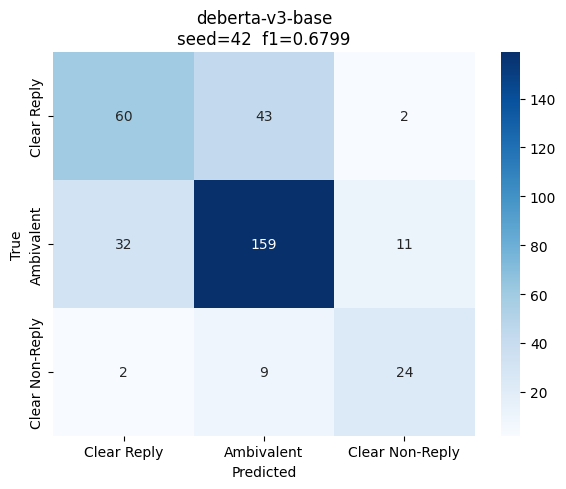

Saved → /kaggle/working/cm_per_model.png


In [94]:
# Cell 6 — Confusion matrix for best run per model (loads val_preds from disk)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

label_names = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

best_per_model = {}
for r in sweep_results:
    model_key = r["cfg"].model_name.split("/")[-1]
    if model_key not in best_per_model or r["val_f1_macro"] > best_per_model[model_key]["val_f1_macro"]:
        best_per_model[model_key] = r

fig, axes = plt.subplots(1, len(best_per_model), figsize=(6 * len(best_per_model), 5))
if len(best_per_model) == 1:
    axes = [axes]

for ax, (model_name, r) in zip(axes, best_per_model.items()):
    val_logits = np.load(Path(r["run_dir"]) / "val_preds.npy")
    val_labels = np.load(Path(r["run_dir"]) / "val_labels.npy")
    preds = val_logits.argmax(axis=1)
    cm = confusion_matrix(val_labels, preds, labels=[0, 1, 2])
    print(f"{model_name} (seed={r['cfg'].seed}, f1={r['val_f1_macro']:.4f}) cm={cm.tolist()}")
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names,
                cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_name}\nseed={r['cfg'].seed}  f1={r['val_f1_macro']:.4f}")

plt.tight_layout()
plt.savefig("/kaggle/working/cm_per_model.png", dpi=150)
plt.show()
print("Saved → /kaggle/working/cm_per_model.png")

In [95]:
# Cell 6b - Validation error analysis for preprocessing decisions
import re
import pandas as pd
import numpy as np
from pathlib import Path

label_names_map = {0: "Clear Reply", 1: "Ambivalent", 2: "Clear Non-Reply"}

def has_any(text, patterns):
    text = str(text).lower()
    return int(any(re.search(p, text) for p in patterns))

def add_error_patterns(df):
    out = df.copy()
    q = out["question_orig"].astype(str).str.lower()
    a = out["answer_orig"].astype(str).str.lower()
    a_open = a.str.split().str[:14].str.join(" ")

    out["p_answer_has_year"] = a.str.contains(r"\b(?:18|19|20)\d{2}\b", regex=True).astype(int)
    out["p_answer_has_money"] = a.str.contains(r"[$€£]|\b(dollars?|euros?|pounds?|usd|eur|gbp|million|billion|trillion)\b", regex=True).astype(int)
    out["p_answer_has_percent"] = a.str.contains(r"\b\d+(?:\.\d+)?\s?(?:%|percent)\b", regex=True).astype(int)
    out["p_answer_has_number"] = a.str.contains(r"\b\d+(?:[,.]\d+)*(?:\.\d+)?\b", regex=True).astype(int)
    out["p_answer_has_causal"] = a.str.contains(r"\b(because|therefore|as a result|reason)\b", regex=True).astype(int)
    out["p_answer_has_uncertain"] = a.str.contains(r"\b(maybe|perhaps|probably|possibly|i think|i believe|it depends|not sure)\b", regex=True).astype(int)
    out["p_answer_has_nonreply"] = a.str.contains(r"\b(no comment|not going to answer|can't answer|cannot answer|do not know|don't know|decline to)\b", regex=True).astype(int)
    out["p_answer_opens_yesno"] = a_open.str.contains(r"^(yes|yeah|absolutely|certainly|sure|no|not really|never)\b", regex=True).astype(int)
    out["p_answer_opens_deflect"] = a_open.str.contains(r"^(well|look|let me|first of all)\b", regex=True).astype(int)
    out["p_multi_question"] = out.get("multiple_questions", pd.Series(False, index=out.index)).fillna(False).astype(int)
    out["p_affirmative_question"] = out.get("affirmative_questions", pd.Series(False, index=out.index)).fillna(False).astype(int)
    out["p_long_answer"] = (out["answer_orig"].astype(str).str.split().str.len() >= 180).astype(int)
    out["p_short_answer"] = (out["answer_orig"].astype(str).str.split().str.len() <= 35).astype(int)
    return out

def rebuild_validation_frame(cfg):
    train_df, _ = load_clarity()
    cleaned = encode_labels(clean_data(train_df))
    train_idx, val_idx = create_split(cleaned, val_size=0.1, seed=cfg.split_id)
    val_orig = cleaned.iloc[val_idx].reset_index(drop=True).copy()
    val_trans = apply_text_transforms_for_config(val_orig, cfg)
    out = val_orig.copy()
    out["question_orig"] = val_orig["question"].astype(str)
    out["answer_orig"] = val_orig["answer"].astype(str)
    out["question_model"] = val_trans["question"].astype(str)
    out["answer_model"] = val_trans["answer"].astype(str)
    return out

pattern_cols = [
    "p_answer_has_year", "p_answer_has_money", "p_answer_has_percent", "p_answer_has_number",
    "p_answer_has_causal", "p_answer_has_uncertain", "p_answer_has_nonreply",
    "p_answer_opens_yesno", "p_answer_opens_deflect", "p_multi_question",
    "p_affirmative_question", "p_long_answer", "p_short_answer",
]

for r in sorted(sweep_results, key=lambda x: x["val_f1_macro"], reverse=True):
    cfg = r["cfg"]
    run_dir = Path(r["run_dir"])
    val_logits = np.load(run_dir / "val_preds.npy")
    val_labels = np.load(run_dir / "val_labels.npy")
    preds = val_logits.argmax(axis=1)

    err = rebuild_validation_frame(cfg)
    err["gold_id"] = val_labels
    err["pred_id"] = preds
    err["gold"] = [label_names_map[int(x)] for x in val_labels]
    err["pred"] = [label_names_map[int(x)] for x in preds]
    err["correct"] = err["gold_id"] == err["pred_id"]
    err["confidence"] = softmax_np(val_logits).max(axis=1)
    err = add_error_patterns(err)
    wrong = err[~err["correct"]].copy()

    print("\n" + "=" * 90)
    print(r["run_id"])
    print(f"val_f1_macro={r['val_f1_macro']:.4f}  wrong={len(wrong)}/{len(err)}")
    print("\nConfusions:")
    display(pd.crosstab(err["gold"], err["pred"], rownames=["gold"], colnames=["pred"]))

    print("\nPattern rate in wrong vs correct validation rows:")
    summary = pd.DataFrame({
        "wrong_rate": wrong[pattern_cols].mean(),
        "correct_rate": err[err["correct"]][pattern_cols].mean(),
    })
    summary["gap_wrong_minus_correct"] = summary["wrong_rate"] - summary["correct_rate"]
    display(summary.sort_values("gap_wrong_minus_correct", ascending=False).round(3))

    print("\nMost confident wrong examples:")
    cols = [
        "index", "gold", "pred", "confidence",
        "question_orig", "answer_orig", "question_model", "answer_model",
    ]
    display(
        wrong.sort_values("confidence", ascending=False)[cols]
        .head(12)
        .style.set_properties(subset=["question_orig", "answer_orig", "question_model", "answer_model"], **{"white-space": "pre-wrap"})
    )

    print("\nWrong examples by confusion type:")
    for (gold, pred), grp in wrong.groupby(["gold", "pred"]):
        print(f"\n--- {gold} -> {pred}: {len(grp)} rows ---")
        display(
            grp.sort_values("confidence", ascending=False)[cols]
            .head(5)
            .style.set_properties(subset=["question_orig", "answer_orig", "question_model", "answer_model"], **{"white-space": "pre-wrap"})
        )


deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed
val_f1_macro=0.6799  wrong=99/342

Confusions:


/tmp/ipykernel_57/1315830222.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out["p_answer_has_money"] = a.str.contains(r"[$€£]|\b(dollars?|euros?|pounds?|usd|eur|gbp|million|billion|trillion)\b", regex=True).astype(int)
/tmp/ipykernel_57/1315830222.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out["p_answer_has_causal"] = a.str.contains(r"\b(because|therefore|as a result|reason)\b", regex=True).astype(int)
/tmp/ipykernel_57/1315830222.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out["p_answer_has_uncertain"] = a.str.contains(r"\b(maybe|perhaps|probably|possibly|i think|i believe|it depends|not sure)\b", regex=True).astype(int)
/tmp/ipykernel_57/1315830222.py:25: UserWarning: This pattern is interpreted 

pred,Ambivalent,Clear Non-Reply,Clear Reply
gold,,,
Ambivalent,159,11,32
Clear Non-Reply,9,24,2
Clear Reply,43,2,60



Pattern rate in wrong vs correct validation rows:


,wrong_rate,correct_rate,gap_wrong_minus_correct
p_long_answer,0.596,0.506,0.090
p_answer_has_number,0.404,0.354,0.050
p_answer_has_money,0.141,0.119,0.022
p_answer_has_causal,0.485,0.465,0.020
p_answer_has_uncertain,0.566,0.551,0.014
p_affirmative_question,0.242,0.230,0.012
p_answer_opens_yesno,0.162,0.152,0.009
p_multi_question,0.020,0.016,0.004
p_answer_opens_deflect,0.263,0.280,-0.017
p_answer_has_percent,0.040,0.062,-0.021


...

,index,gold,pred,confidence,question_orig,answer_orig,question_model,answer_model
215,1569,Clear Non-Reply,Clear Reply,0.846292,"Is there a transcript of your conversation, your private conversation?","Mike, do they have a transcript? They probably have a rough transcript, which you can give us, if you have one.","Is there a transcript of your conversation, your private conversation?","Mike, do they have a transcript? They probably have a rough transcript, which you can give us, if you have one."
284,10,Clear Non-Reply,Clear Reply,0.755399,What did you talk about with him?,"We talked about what we talked about at the conference overall. We talked about stability. We talked about making sure that the Third Worldtheexcuse meThird Worldthe Southern Hemisphere had access to change, it had accessweit wasn't confrontational at all. He came up to me. He said[inaudible]. Thankthank you, everybody. The President. Thank This ends the press conference. Thanks, everyone. The President. Thank you. Thank you.[]",What did you talk about with him?,"We talked about what we talked about at the conference overall. We talked about stability. We talked about making sure that the Third Worldtheexcuse meThird Worldthe Southern Hemisphere had access to change, it had accessweit was not confrontational at all. He came up to me. He said[inaudible]. Thankthank you, everybody. The President. Thank This ends the press conference. Thanks, everyone. The President. Thank you. Thank you.[]"
116,2202,Clear Non-Reply,Clear Reply,0.608553,How and when will Asad go?,"We would have preferred Asad go 2 years ago, last year, 6 months ago, 2 months ago. And there has been consistency on the part of my administration that Asad lost legitimacy when he started firing on his own people and killing his own people, who initially were protesting peacefully for a greater voice in their country's affairs. And obviously, that's escalated during the course of time. So the answer is, the sooner the better.Now, in terms of the question how, I think we've already discussed that. There's no magic formula for dealing with a extraordinarily violent and difficult situation like 's. If there was, I think the Prime Minister and I would have already acted on it and it would already be finished.And instead, what we have to do is apply steady international pressure, strengthen the opposition. I do think that the prospect of talks in Geneva, involving the Russians and representatives, about a serious political transition that all the parties can buy into may yield results. But in the meantime, we're going to continue to make sure that we're helping the opposition and obviously dealing with the humanitarian situation. And we'll do so in close consultation with Turkey, which obviously is deeply invested in this and with whom we've got an outstanding relationship with.. Thank you very much. As you know, we will be meeting again this evening, so we'll have time to go in further detail. As I said before, our views do overlap, and with our discussions this evening, we will continue to explore what we can do together, what we can consider as parts of a roadmap looking at Geneva and beyond.Russia and China being part of this process is very important, and this is important in the context of the permanent members of the U.N. Security Council. Their participation in this process will certainly add greater impetus. The pressure of the international community continues to be a very important element, and when we look at the humanitarian support that we have provided so far, we see that support equaling to more than $1½ billion.And we continue to keep an open door policy, and we will continue to do this because we have a border which is 910 kilometers in length with ; we have—there are relatives across the border on each side. So we will continue these efforts.These are all very important for regional peace, because, on the one hand, you have the steps that have been taken, efforts that are in place to 


--- Clear Reply -> Ambivalent: 33 rows ---


,index,gold,pred,confidence,question_orig,answer_orig,question_model,answer_model
294,1566,Clear Reply,Ambivalent,0.981425,What do you think about the involvement of South Korea and China as the signatories?,I'd like to have them involved also.,What do you think about the involvement of South Korea and China as the signatories?,I'd like to have them involved also.
129,3214,Clear Reply,Ambivalent,0.975572,So there was no choice between the course we took and leaving Saddam Hussein in power?,"Well, we tried other things. As you might remember back then, we tried the diplomatic route: 1441 was a unanimous vote in the Security Council that said disclose, disarm, or face serious consequences. So the choice was his to make. And he made a choice that has subsequently left—subsequently caused him to lose his life under a system that he wouldn't have given his own citizens. Now, we tried diplomacy. As a matter of fact, not only did I try diplomacy; other Presidents tried diplomacy.Let's see here. John [John McKinnon, Wall Street Journal].",So there was no choice between the course we took and leaving Saddam Hussein in power?,"Well, we tried other things. As you might remember back then, we tried the diplomatic route: number was a unanimous vote in the Security Council that said disclose, disarm, or face serious consequences. So the choice was his to make. And he made a choice that has subsequently left—subsequently caused him to lose his life under a system that he would not have given his own citizens. Now, we tried diplomacy. As a matter of fact, not only did I try diplomacy; other Presidents tried diplomacy.Let's see here. John [John McKinnon, Wall Street Journal]."
120,3079,Clear Reply,Ambivalent,0.942900,Effectiveness in dealing with Democrats on various issues,"We're finding common ground on Iraq. We're—I recognize there are people in Congress that say we shouldn't have been there in the first place. But it sounds to me as if the debate has shifted, that David Petraeus and Ryan Crocker's testimony made a difference to a lot of Members. I hope we continue to find ground by making sure our troops get funded.We found common ground on FISA. My only question is, why change a good law? The way that law was written works for the security of the country. That's what the American people want to know, by the way. Are we passing laws that are beneficial to the American people? This law is beneficial because it enables our intelligence experts to—and professionals to find out the intentions of Al Qaida. Now, the law needs to be changed, enhanced by providing the phone companies that allegedly helped us with liability protection. So we found common ground there.Hopefully, we can find common ground as the Congress begins to move pieces of legislation. The reason I said what I said today is, there's a lot to be done. As you recognize, I'm not a member of the legislative branch; probably wouldn't be a very good legislator. But as the head of the executive branch, it makes sense to call upon Congress to show progress and get results. It's hard to find common ground unless important bills are moving. They're not even moving. And not one appropriations bill has made it to my desk. How can you find common ground when there's no appropriations process?We found common ground on a trade bill—trade bills, really important pieces of legislation, as far as I'm concerned. One of the reasons why is, exports helped us overcome the weakness in the housing market last quarter. If that's the case, it seems like it makes sense to continue and open up markets to goods and services. And yet there hadn't been one—there haven't been any bills moving when it comes to trade.Veterans Affairs is an area where we can find common ground. I've called in—I asked Bob Dole and Donna Shalala to lead an important Commission, a Commission to make sure our veterans get the benefits they deserve. I was concerned about bureaucratic delay and the—concerned about a system that had be


--- Clear Reply -> Clear Non-Reply: 1 rows ---


,index,gold,pred,confidence,question_orig,answer_orig,question_model,answer_model
113,3004,Clear Reply,Clear Non-Reply,0.915406,Did you ask President George Bush to request Israel to fully freeze settlements in order to enable successful negotiations?,"Yes, but tell me the part about the U.N. thing again? What were you—I couldn't understand you very well.",Did you ask President George Bush to request Israel to fully freeze settlements in order to enable successful negotiations?,"Yes, but tell me the part about the U.N. thing again? What were you—I could not understand you very well."


In [96]:
# Cell 7 - Generate single-seed and ensemble submission CSVs
import gc
import shutil
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score

label_names_map = {0: "Clear Reply", 1: "Ambivalent", 2: "Clear Non-Reply"}

def softmax_np(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def load_run_logits_for_test(r):
    cfg = r["cfg"]
    run_dir = Path(r["run_dir"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if cfg.use_dual_view:
        feature_stats = load_feature_stats(run_dir / "feature_stats.json")
        evasion_stack_model = None
        reload_model, reload_tok = load_dual_view_feature_model_and_tokenizer(
            cfg.model_name,
            num_labels=NUM_LABELS,
            num_features=len(feature_stats["feature_names"]),
            feature_hidden=cfg.numeric_feature_hidden,
        )
    elif cfg.use_numeric_features:
        feature_stats = load_feature_stats(run_dir / "feature_stats.json")
        evasion_stack_model = (
            load_evasion_stack_model(run_dir / "evasion_stack.joblib")
            if cfg.use_evasion_proba_features else None
        )
        reload_model, reload_tok = load_feature_model_and_tokenizer(
            cfg.model_name,
            num_labels=NUM_LABELS,
            num_features=len(feature_stats["feature_names"]),
            feature_hidden=cfg.numeric_feature_hidden,
        )
    else:
        feature_stats = None
        evasion_stack_model = None
        reload_model, reload_tok = load_model_and_tokenizer(cfg.model_name, num_labels=NUM_LABELS)

    extra_tokens = special_tokens_for_config(cfg)
    if extra_tokens:
        added = ensure_special_tokens(extra_tokens, reload_tok, reload_model)
        print(f"[reload] re-added {added} special tokens before loading checkpoint")
    reload_model.load_state_dict(torch.load(run_dir / "best_model.pt", map_location=device))
    reload_model.to(device)
    reload_model.eval()

    _, test_df = load_clarity()
    test_df_enc = test_df.copy()
    test_df_enc["label_id"] = 0
    test_df_enc = apply_text_transforms_for_config(test_df_enc, cfg)

    if cfg.use_dual_view:
        test_features = transform_numeric_features(test_df_enc, feature_stats)
        test_df_second = test_df.copy()
        test_df_second["label_id"] = 0
        test_df_second = apply_text_transforms_for_config(test_df_second, cfg, answer_view="focused")
        test_ds = tokenize_dual_view_pairs_with_features(
            test_df_enc,
            test_df_second,
            reload_tok,
            cfg.max_length,
            cfg.input_fmt,
            test_features,
        )
    elif cfg.use_numeric_features:
        test_features = transform_numeric_features(test_df_enc, feature_stats)
        if cfg.use_evasion_proba_features:
            evasion_probs = transform_evasion_stack_features(test_df_enc, evasion_stack_model)
            test_features = np.concatenate([test_features, evasion_probs], axis=1)
        test_ds = tokenize_pairs_with_features(
            test_df_enc, reload_tok, cfg.max_length, cfg.input_fmt, test_features
        )
    else:
        test_ds = tokenize_pairs(test_df_enc, reload_tok, cfg.max_length, cfg.input_fmt)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, sampler=SequentialSampler(test_ds))

    all_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = [b.to(device) for b in batch]
            if len(batch) == 6:
                input_ids, attention_mask, input_ids_2, attention_mask_2, labels, features = batch
                out = reload_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    input_ids_2=input_ids_2,
                    attention_mask_2=attention_mask_2,
                    features=features,
                )
            else:
                input_ids, attention_mask, labels = batch[:3]
            if len(batch) == 4:
                out = reload_model(input_ids=input_ids, attention_mask=attention_mask, features=batch[3])
            elif len(batch) != 6:
                out = reload_model(input_ids=input_ids, attention_mask=attention_mask)
            all_logits.append(out.logits.cpu().numpy())
    test_logits = np.concatenate(all_logits, axis=0)

    reload_model.cpu()
    del reload_model, reload_tok
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return test_df, test_logits

def write_submission(name, test_df, preds):
    submission = pd.DataFrame({
        "Id": test_df["index"] if "index" in test_df.columns else range(len(test_df)),
        "Predicted": [label_names_map[int(p)] for p in preds],
    })
    path = f"/kaggle/working/{name}.csv"
    submission.to_csv(path, index=False)
    print(f"{name}.csv -> {path}")
    print(f"  Distribution: {dict(submission['Predicted'].value_counts())}")
    return path

all_runs = sorted(sweep_results, key=lambda r: r["val_f1_macro"], reverse=True)
val_labels_ref = np.load(Path(all_runs[0]["run_dir"]) / "val_labels.npy")

test_df_ref = None
val_probs = []
test_probs = []
for r in all_runs:
    val_logits = np.load(Path(r["run_dir"]) / "val_preds.npy")
    val_probs.append(softmax_np(val_logits))
    test_df_ref, test_logits = load_run_logits_for_test(r)
    test_probs.append(softmax_np(test_logits))
    safe_id = r["run_id"].replace("/", "_")
    write_submission(f"submission_single_{safe_id}", test_df_ref, test_logits.argmax(axis=1))

best_single = all_runs[0]
print(f"Best single: {best_single['run_id']} val={best_single['val_f1_macro']:.4f}")

equal_val = np.mean(val_probs, axis=0)
equal_test = np.mean(test_probs, axis=0)
equal_f1 = f1_score(val_labels_ref, equal_val.argmax(axis=1), average="macro", zero_division=0)
equal_path = write_submission("submission_equal_phase19_dualview", test_df_ref, equal_test.argmax(axis=1))
print(f"Equal ensemble val F1: {equal_f1:.4f}")

grid = np.linspace(0.0, 1.0, 21)
best = (-1.0, None)
if len(val_probs) == 1:
    best = (all_runs[0]["val_f1_macro"], np.array([1.0], dtype=np.float32))
elif len(val_probs) == 2:
    for a in grid:
        weights = np.array([a, 1.0 - a], dtype=np.float32)
        ens = sum(w * p for w, p in zip(weights, val_probs))
        f1 = f1_score(val_labels_ref, ens.argmax(axis=1), average="macro", zero_division=0)
        if f1 > best[0]:
            best = (f1, weights)
else:
    for a in grid:
        for b in grid:
            c = 1.0 - a - b
            if c < -1e-9:
                continue
            weights = np.array([a, b, c], dtype=np.float32)
            ens = sum(w * p for w, p in zip(weights, val_probs))
            f1 = f1_score(val_labels_ref, ens.argmax(axis=1), average="macro", zero_division=0)
            if f1 > best[0]:
                best = (f1, weights)

best_f1, best_w = best
alpha_test = sum(w * p for w, p in zip(best_w, test_probs))
alpha_path = write_submission("submission_alpha_phase19_dualview", test_df_ref, alpha_test.argmax(axis=1))
print(f"Alpha ensemble val F1: {best_f1:.4f}, weights={best_w.tolist()}")

chosen = alpha_path if best_f1 >= equal_f1 else equal_path
shutil.copyfile(chosen, "/kaggle/working/submission.csv")
print(f"Default /kaggle/working/submission.csv copied from: {chosen}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


submission_single_deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed.csv -> /kaggle/working/submission_single_deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed.csv
  Distribution: {'Ambivalent': np.int64(194), 'Clear Reply': np.int64(89), 'Clear Non-Reply': np.int64(25)}


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


submission_single_deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed.csv -> /kaggle/working/submission_single_deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed.csv
  Distribution: {'Ambivalent': np.int64(196), 'Clear Reply': np.int64(86), 'Clear Non-Reply': np.int64(26)}


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


submission_single_deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_numfeat_long_mixed.csv -> /kaggle/working/submission_single_deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_numfeat_long_mixed.csv
  Distribution: {'Ambivalent': np.int64(181), 'Clear Reply': np.int64(111), 'Clear Non-Reply': np.int64(16)}


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


submission_single_deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_focused_numfeat_long_mixed.csv -> /kaggle/working/submission_single_deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_focused_numfeat_long_mixed.csv
  Distribution: {'Ambivalent': np.int64(210), 'Clear Reply': np.int64(75), 'Clear Non-Reply': np.int64(23)}


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


submission_single_deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_wordnorm_numfeat_long_mixed.csv -> /kaggle/working/submission_single_deberta-v3-base_two_segment_lr2e-05_bs8_ep4_ml256_seed42_dualview_wordnorm_numfeat_long_mixed.csv
  Distribution: {'Ambivalent': np.int64(172), 'Clear Reply': np.int64(115), 'Clear Non-Reply': np.int64(21)}
Best single: deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed val=0.6799
submission_equal_phase19_dualview.csv -> /kaggle/working/submission_equal_phase19_dualview.csv
  Distribution: {'Ambivalent': np.int64(193), 'Clear Reply': np.int64(93), 'Clear Non-Reply': np.int64(22)}
Equal ensemble val F1: 0.6786
submission_alpha_phase19_dualview.csv -> /kaggle/working/submission_alpha_phase19_dualview.csv
  Distribution: {'Ambivalent': np.int64(197), 'Clear Reply': np.int64(87), 'Clear Non-Reply': np.int64(24)}
Alpha ensemble val F1: 0.6888, weights=[0.6499999761581421, 0.20000000298023224, 0.15000000596046448]
D

In [97]:
# Cell 7b - Optional class-multiplier calibration for current ensemble
# This does not retrain. It searches class multipliers on validation probabilities
# and applies the best multipliers to the already-computed alpha test probabilities.
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import shutil

if "best_w" not in globals() or "val_probs" not in globals() or "test_probs" not in globals():
    raise RuntimeError("Run Cell 7 first so alpha ensemble probabilities exist.")

alpha_val = sum(w * p for w, p in zip(best_w, val_probs))
alpha_test = sum(w * p for w, p in zip(best_w, test_probs))
base_alpha_f1 = f1_score(val_labels_ref, alpha_val.argmax(axis=1), average="macro", zero_division=0)

grid = np.arange(0.70, 1.31, 0.05)
best_cal = (base_alpha_f1, np.array([1.0, 1.0, 1.0], dtype=np.float32))
for cr in grid:
    for amb in grid:
        for cnr in grid:
            mult = np.array([cr, amb, cnr], dtype=np.float32)
            pred = (alpha_val * mult).argmax(axis=1)
            f1 = f1_score(val_labels_ref, pred, average="macro", zero_division=0)
            if f1 > best_cal[0]:
                best_cal = (f1, mult)

cal_f1, cal_mult = best_cal
cal_test_pred = (alpha_test * cal_mult).argmax(axis=1)
cal_path = write_submission("submission_alpha_phase19_dualview_calibrated", test_df_ref, cal_test_pred)

print(f"Base alpha val F1:       {base_alpha_f1:.4f}")
print(f"Calibrated alpha val F1: {cal_f1:.4f}")
print(f"Class multipliers [CR, AMB, CNR]: {cal_mult.tolist()}")
print(f"Calibrated CSV: {cal_path}")

if cal_f1 >= base_alpha_f1:
    shutil.copyfile(cal_path, "/kaggle/working/submission_calibrated.csv")
    print("Copied calibrated file to /kaggle/working/submission_calibrated.csv")
else:
    print("Calibration did not improve validation; keep /kaggle/working/submission.csv")

submission_alpha_phase19_dualview_calibrated.csv -> /kaggle/working/submission_alpha_phase19_dualview_calibrated.csv
  Distribution: {'Ambivalent': np.int64(172), 'Clear Reply': np.int64(112), 'Clear Non-Reply': np.int64(24)}
Base alpha val F1:       0.6888
Calibrated alpha val F1: 0.6913
Class multipliers [CR, AMB, CNR]: [1.0499999523162842, 0.699999988079071, 0.699999988079071]
Calibrated CSV: /kaggle/working/submission_alpha_phase19_dualview_calibrated.csv
Copied calibrated file to /kaggle/working/submission_calibrated.csv


In [98]:
# Cell 8 — Download this session's run directories
import shutil, os
from pathlib import Path
from IPython.display import FileLink, display

# zip only the runs from this sweep, not the entire models dir
session_zip_base = "/kaggle/working/session_models"
session_tmp = Path("/kaggle/working/session_models_tmp")
session_tmp.mkdir(exist_ok=True)

for cfg in sweep_configs:
    src = Path(cfg.models_dir) / cfg.run_id
    if src.exists():
        dst = session_tmp / cfg.run_id
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"  included: {cfg.run_id}")
    else:
        print(f"  MISSING:  {cfg.run_id}")

shutil.make_archive(session_zip_base, "zip", str(session_tmp))
shutil.rmtree(session_tmp)

print(f"\nZip created: session_models.zip")
display(FileLink("session_models.zip"))

  included: deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_numfeat_long_mixed


Error: [('/kaggle/working/models_phase19_dualview/deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed/best_model.pt', '/kaggle/working/session_models_tmp/deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed/best_model.pt', "[Errno 28] No space left on device: '/kaggle/working/models_phase19_dualview/deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed/best_model.pt' -> '/kaggle/working/session_models_tmp/deberta-v3-base_two_segment_lr2e-05_bs16_ep4_ml256_seed42_wordnorm_numfeat_long_mixed/best_model.pt'")]